# PubMedQA Schema Analysis (Baseline, L1-L6) - Comprehensive Metrics

This notebook analyzes the Baseline and L1-L6 schema-constrained results for PubMedQA, including answer distribution with invalid JSON cases, schema compliance metrics, confidence score analysis, reasoning length statistics, and key_evidence analysis.


In [18]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Set style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


## Load L1 Results and Samples


In [19]:
# Load L1 result JSON
l1_result_file = "pubmedqa_level1_2025-12-08T14-28-16.793274.json"

with open(l1_result_file, 'r') as f:
    l1_results = json.load(f)

l1_exact_match = l1_results['results']['pubmedqa_generation']['exact_match,strict-match']
l1_exact_match_stderr = l1_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L1 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l1_exact_match:.4f} ± {l1_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l1_exact_match*100:.2f}%")
print("="*60)


L1 PERFORMANCE METRICS
Exact Match Score: 0.7720 ± 0.0188
Exact Match Percentage: 77.20%


## Load Baseline Results


In [20]:
# Load baseline result JSON from pubmedqa_new directory
baseline_result_file = "../pubmedqa_new/pubmedqa_baseline_2025-12-02T17-10-15.514633.json"

with open(baseline_result_file, 'r') as f:
    baseline_results = json.load(f)

baseline_exact_match = baseline_results['results']['pubmedqa_generation']['exact_match,strict-match']
baseline_exact_match_stderr = baseline_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("BASELINE PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {baseline_exact_match:.4f} ± {baseline_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {baseline_exact_match*100:.2f}%")
print("="*60)


BASELINE PERFORMANCE METRICS
Exact Match Score: 0.7620 ± 0.0191
Exact Match Percentage: 76.20%


## Load L2 Results


In [21]:
# Load L2 result JSON
l2_result_file = "pubmedqa_level2_2025-12-08T14-33-38.031833.json"

with open(l2_result_file, 'r') as f:
    l2_results = json.load(f)

l2_exact_match = l2_results['results']['pubmedqa_generation']['exact_match,strict-match']
l2_exact_match_stderr = l2_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L2 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l2_exact_match:.4f} ± {l2_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l2_exact_match*100:.2f}%")
print("="*60)

# Comparison with Baseline and L1
print("\n" + "="*60)
print("BASELINE vs L1 vs L2 COMPARISON")
print("="*60)
print(f"Baseline: {baseline_exact_match*100:.2f}% ± {baseline_exact_match_stderr*100:.2f}%")
print(f"L1:       {l1_exact_match*100:.2f}% ± {l1_exact_match_stderr*100:.2f}%")
print(f"L2:       {l2_exact_match*100:.2f}% ± {l2_exact_match_stderr*100:.2f}%")
diff_l1 = (l1_exact_match - baseline_exact_match) * 100
diff_l2 = (l2_exact_match - baseline_exact_match) * 100
diff_l2_l1 = (l2_exact_match - l1_exact_match) * 100
print(f"\nL1 vs Baseline: {diff_l1:+.2f} percentage points")
print(f"L2 vs Baseline: {diff_l2:+.2f} percentage points")
print(f"L2 vs L1: {diff_l2_l1:+.2f} percentage points")
print("="*60)


L2 PERFORMANCE METRICS
Exact Match Score: 0.7740 ± 0.0187
Exact Match Percentage: 77.40%

BASELINE vs L1 vs L2 COMPARISON
Baseline: 76.20% ± 1.91%
L1:       77.20% ± 1.88%
L2:       77.40% ± 1.87%

L1 vs Baseline: +1.00 percentage points
L2 vs Baseline: +1.20 percentage points
L2 vs L1: +0.20 percentage points


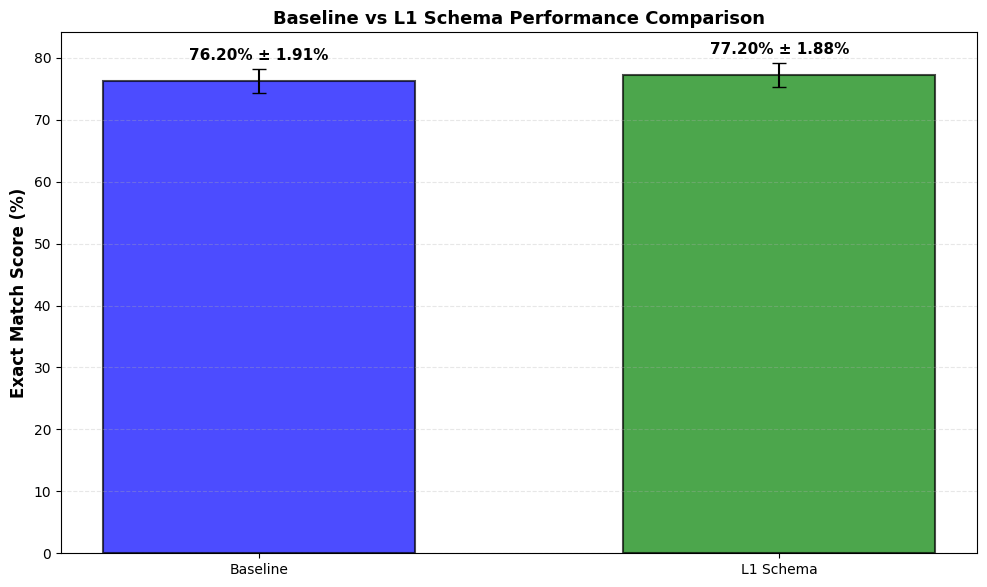

In [22]:
# Visualize Baseline vs L1 comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['Baseline', 'L1 Schema']
scores = [baseline_exact_match * 100, l1_exact_match * 100]
errors = [baseline_exact_match_stderr * 100, l1_exact_match_stderr * 100]

x_pos = np.arange(len(models))
bars = ax.bar(x_pos, scores, yerr=errors, capsize=5, 
              color=['blue', 'green'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)

for i, (bar, score, error) in enumerate(zip(bars, scores, errors)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + error + 1,
            f'{score:.2f}% ± {error:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Exact Match Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Baseline vs L1 Schema Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim([0, max(scores) + max(errors) + 5])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Baseline Answer Distribution Analysis


In [23]:
# Load baseline samples and extract answer distribution
baseline_samples_file = "../pubmedqa_new/samples_pubmedqa_generation_baseline.jsonl"

baseline_answers = []
baseline_responses = []
baseline_filtered_responses = []

with open(baseline_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Extract answer from filtered_resp (baseline uses regex extraction)
        answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        baseline_answers.append(answer)
        baseline_responses.append(raw_resp if raw_resp else '')
        baseline_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
baseline_answer_counts = Counter(baseline_answers)
baseline_categories = ['yes', 'no', 'maybe', '[invalid]']
baseline_counts = [baseline_answer_counts.get(cat, 0) for cat in baseline_categories]

baseline_total = len(baseline_answers)

print("="*60)
print("BASELINE ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution:")
for cat, count in zip(baseline_categories, baseline_counts):
    percentage = count / baseline_total * 100 if baseline_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {baseline_total}")
print(f"Valid answers (yes+no+maybe): {sum(baseline_counts[:3])} ({sum(baseline_counts[:3])/baseline_total*100:.2f}%)")
print(f"Invalid answers: {baseline_counts[3]} ({baseline_counts[3]/baseline_total*100:.2f}%)")
print("="*60)


BASELINE ANSWER DISTRIBUTION

Answer Distribution:
  yes         :  344 (68.80%)
  no          :  151 (30.20%)
  maybe       :    2 ( 0.40%)
  [invalid]   :    3 ( 0.60%)

Total samples: 500
Valid answers (yes+no+maybe): 497 (99.40%)
Invalid answers: 3 (0.60%)


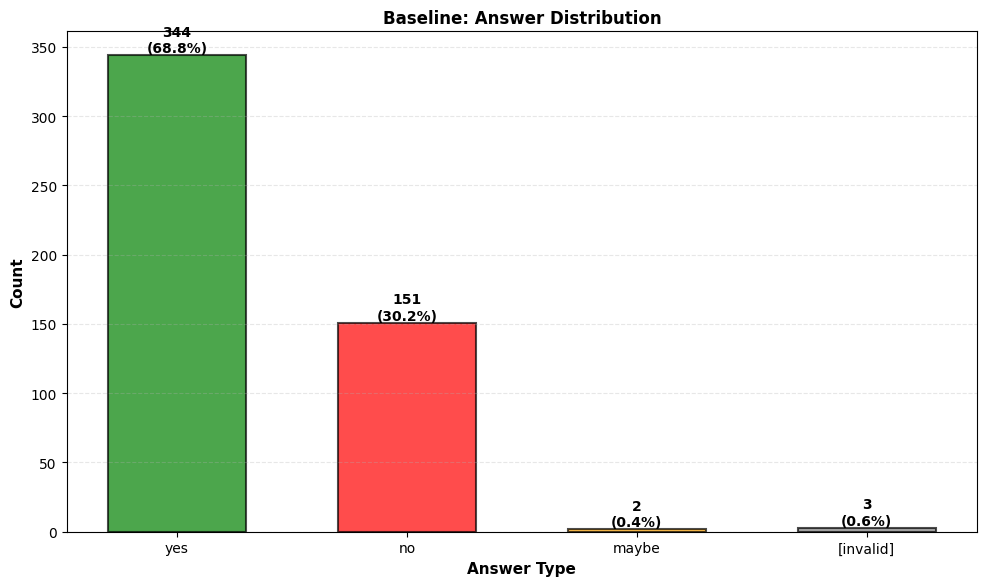

In [24]:
# Visualize Baseline Answer Distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x_pos = np.arange(len(baseline_categories))
bars = ax.bar(x_pos, baseline_counts, color=['green', 'red', 'orange', 'gray'], 
              alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)

for bar, count in zip(bars, baseline_counts):
    height = bar.get_height()
    percentage = count / baseline_total * 100 if baseline_total > 0 else 0
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Baseline: Answer Distribution', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(baseline_categories, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Answer Distribution Analysis (Including Invalid JSON)


In [25]:
# Load L1 samples and extract data
l1_samples_file = "samples_pubmedqa_generation_L1.jsonl"

l1_answers = []
l1_valid_json = []
l1_has_answer = []
l1_answer_valid = []
l1_responses = []
l1_filtered_responses = []

# Helper function to extract JSON by finding matching braces
def extract_json_from_text(text):
    """Extract JSON from text, handling incomplete JSON."""
    if not text or not isinstance(text, str):
        return None
    
    text_cleaned = text.strip()
    
    # Try direct parse first (most common case)
    try:
        return json.loads(text_cleaned)
    except (json.JSONDecodeError, TypeError):
        pass
    
    # Try to find complete JSON object using balanced braces
    start_idx = text_cleaned.find('{')
    if start_idx == -1:
        return None
    
    # Count braces to find the matching closing brace
    brace_count = 0
    for i in range(start_idx, len(text_cleaned)):
        if text_cleaned[i] == '{':
            brace_count += 1
        elif text_cleaned[i] == '}':
            brace_count -= 1
            if brace_count == 0:
                # Found matching closing brace
                json_str = text_cleaned[start_idx:i+1]
                try:
                    return json.loads(json_str)
                except (json.JSONDecodeError, TypeError):
                    return None
    return None

with open(l1_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        has_answer_field = False
        answer_is_valid_enum = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l1_answers.append(answer)
        l1_valid_json.append(json_valid)
        l1_has_answer.append(has_answer_field)
        l1_answer_valid.append(answer_is_valid_enum)
        l1_responses.append(raw_resp if raw_resp else '')
        l1_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l1_answer_counts = Counter(l1_answers)
l1_categories = ['yes', 'no', 'maybe', '[invalid]']
l1_counts = [l1_answer_counts.get(cat, 0) for cat in l1_categories]

# Calculate schema compliance
l1_total = len(l1_answers)
l1_valid_json_count = sum(l1_valid_json)
l1_compliant = sum([l1_valid_json[i] and l1_has_answer[i] and l1_answer_valid[i] 
                    for i in range(l1_total)])

print("="*60)
print("L1 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l1_categories, l1_counts):
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l1_total}")
print(f"Valid answers (yes+no+maybe): {sum(l1_counts[:3])} ({sum(l1_counts[:3])/l1_total*100:.2f}%)")
print(f"Invalid answers: {l1_counts[3]} ({l1_counts[3]/l1_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l1_valid_json_count}/{l1_total} ({l1_valid_json_count/l1_total*100:.2f}%)")
print(f"  Invalid JSON: {l1_total - l1_valid_json_count}/{l1_total} ({(l1_total - l1_valid_json_count)/l1_total*100:.2f}%)")

print(f"\nAnswer Distribution Breakdown:")
print(f"  Valid JSON with valid answer: {l1_compliant} ({l1_compliant/l1_total*100:.2f}%)")
print(f"  Invalid JSON (fallback to filtered_resp): {l1_total - l1_valid_json_count} ({(l1_total - l1_valid_json_count)/l1_total*100:.2f}%)")
print(f"  Invalid JSON → [invalid] answer: {l1_counts[3]} ({l1_counts[3]/l1_total*100:.2f}%)")
print("="*60)


L1 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  315 (63.00%)
  no          :  185 (37.00%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 500/500 (100.00%)
  Invalid JSON: 0/500 (0.00%)

Answer Distribution Breakdown:
  Valid JSON with valid answer: 500 (100.00%)
  Invalid JSON (fallback to filtered_resp): 0 (0.00%)
  Invalid JSON → [invalid] answer: 0 (0.00%)


## L2 Answer Distribution Analysis (Including Invalid JSON)


In [26]:
# Load L2 samples and extract data
l2_samples_file = "samples_pubmedqa_generation_L2.jsonl"

l2_answers = []
l2_confidences = []
l2_valid_json = []
l2_has_answer = []
l2_has_confidence = []
l2_answer_valid = []
l2_confidence_valid = []
l2_both_fields = []
l2_responses = []
l2_filtered_responses = []

# Reuse the extract_json_from_text function from L1 analysis
# (It's already defined in cell 12, but we'll use it here)

with open(l2_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        confidence = None
        has_answer_field = False
        has_confidence_field = False
        answer_is_valid_enum = False
        confidence_is_valid = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
                
                # Extract confidence
                confidence_val = parsed.get('confidence')
                if confidence_val is not None:
                    try:
                        confidence = float(confidence_val)
                        has_confidence_field = True
                        confidence_is_valid = (0.0 <= confidence <= 1.0)
                    except (ValueError, TypeError):
                        confidence = None
                        has_confidence_field = False
                        confidence_is_valid = False
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l2_answers.append(answer)
        l2_confidences.append(confidence)
        l2_valid_json.append(json_valid)
        l2_has_answer.append(has_answer_field)
        l2_has_confidence.append(has_confidence_field)
        l2_answer_valid.append(answer_is_valid_enum)
        l2_confidence_valid.append(confidence_is_valid)
        l2_both_fields.append(has_answer_field and has_confidence_field)
        l2_responses.append(raw_resp if raw_resp else '')
        l2_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l2_answer_counts = Counter(l2_answers)
l2_categories = ['yes', 'no', 'maybe', '[invalid]']
l2_counts = [l2_answer_counts.get(cat, 0) for cat in l2_categories]

# Calculate schema compliance
l2_total = len(l2_answers)
l2_valid_json_count = sum(l2_valid_json)
l2_compliant = sum([l2_valid_json[i] and l2_has_answer[i] and l2_has_confidence[i] 
                     and l2_answer_valid[i] and l2_confidence_valid[i] 
                     for i in range(l2_total)])

print("="*60)
print("L2 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l2_categories, l2_counts):
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l2_total}")
print(f"Valid answers (yes+no+maybe): {sum(l2_counts[:3])} ({sum(l2_counts[:3])/l2_total*100:.2f}%)")
print(f"Invalid answers: {l2_counts[3]} ({l2_counts[3]/l2_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l2_valid_json_count}/{l2_total} ({l2_valid_json_count/l2_total*100:.2f}%)")
print(f"  Invalid JSON: {l2_total - l2_valid_json_count}/{l2_total} ({(l2_total - l2_valid_json_count)/l2_total*100:.2f}%)")

print(f"\nSchema Compliance:")
print(f"  Has answer field: {sum(l2_has_answer)}/{l2_total} ({sum(l2_has_answer)/l2_total*100:.2f}%)")
print(f"  Has confidence field: {sum(l2_has_confidence)}/{l2_total} ({sum(l2_has_confidence)/l2_total*100:.2f}%)")
print(f"  Both fields present: {sum(l2_both_fields)}/{l2_total} ({sum(l2_both_fields)/l2_total*100:.2f}%)")
print(f"  Answer is valid enum: {sum(l2_answer_valid)}/{l2_total} ({sum(l2_answer_valid)/l2_total*100:.2f}%)")
print(f"  Confidence in range [0.0, 1.0]: {sum(l2_confidence_valid)}/{l2_total} ({sum(l2_confidence_valid)/l2_total*100:.2f}%)")
print(f"  Full schema compliance: {l2_compliant}/{l2_total} ({l2_compliant/l2_total*100:.2f}%)")
print("="*60)


L2 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  312 (62.40%)
  no          :  188 (37.60%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 500/500 (100.00%)
  Invalid JSON: 0/500 (0.00%)

Schema Compliance:
  Has answer field: 500/500 (100.00%)
  Has confidence field: 500/500 (100.00%)
  Both fields present: 500/500 (100.00%)
  Answer is valid enum: 500/500 (100.00%)
  Confidence in range [0.0, 1.0]: 500/500 (100.00%)
  Full schema compliance: 500/500 (100.00%)


## L2 Confidence Score Statistics


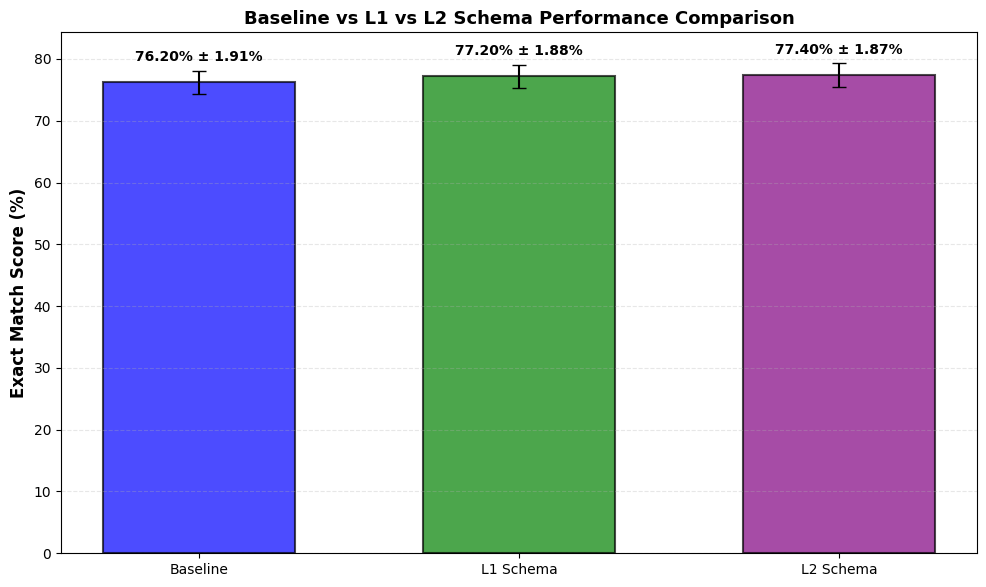

In [27]:
# Performance Metrics Comparison Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['Baseline', 'L1 Schema', 'L2 Schema']
scores = [baseline_exact_match * 100, l1_exact_match * 100, l2_exact_match * 100]
errors = [baseline_exact_match_stderr * 100, l1_exact_match_stderr * 100, l2_exact_match_stderr * 100]

x_pos = np.arange(len(models))
bars = ax.bar(x_pos, scores, yerr=errors, capsize=5, 
              color=['blue', 'green', 'purple'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)

for i, (bar, score, error) in enumerate(zip(bars, scores, errors)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + error + 1,
            f'{score:.2f}% ± {error:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Exact Match Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Baseline vs L1 vs L2 Schema Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim([0, max(scores) + max(errors) + 5])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


In [28]:
# Confidence Score Statistics for L2
l2_valid_confidences = [c for c in l2_confidences if c is not None]

print("="*60)
print("L2 CONFIDENCE SCORE STATISTICS")
print("="*60)

if l2_valid_confidences:
    print(f"Valid confidence scores: {len(l2_valid_confidences)} ({len(l2_valid_confidences)/l2_total*100:.1f}%)")
    print(f"Missing/Invalid confidence: {l2_total - len(l2_valid_confidences)}")
    print(f"\nDescriptive Statistics:")
    print(f"  Mean: {np.mean(l2_valid_confidences):.4f}")
    print(f"  Median: {np.median(l2_valid_confidences):.4f}")
    print(f"  Std Dev: {np.std(l2_valid_confidences):.4f}")
    print(f"  Min: {np.min(l2_valid_confidences):.4f}")
    print(f"  Max: {np.max(l2_valid_confidences):.4f}")
    print(f"  Range: {np.max(l2_valid_confidences) - np.min(l2_valid_confidences):.4f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l2_valid_confidences, p):.4f}")
    
    # Confidence by answer type
    print(f"\nConfidence by Answer Type:")
    for answer_type in ['yes', 'no', 'maybe']:
        conf_by_type = [l2_confidences[i] for i, ans in enumerate(l2_answers) 
                       if ans == answer_type and l2_confidences[i] is not None]
        if conf_by_type:
            print(f"  {answer_type}: mean={np.mean(conf_by_type):.4f}, median={np.median(conf_by_type):.4f}, count={len(conf_by_type)}")
        else:
            print(f"  {answer_type}: No valid confidence scores")
else:
    print("No valid confidence scores found!")
print("="*60)


L2 CONFIDENCE SCORE STATISTICS
Valid confidence scores: 500 (100.0%)
Missing/Invalid confidence: 0

Descriptive Statistics:
  Mean: 0.6432
  Median: 0.5000
  Std Dev: 0.2157
  Min: 0.5000
  Max: 1.0000
  Range: 0.5000

Percentiles:
  25th: 0.5000
  50th: 0.5000
  75th: 0.9000
  90th: 1.0000
  95th: 1.0000

Confidence by Answer Type:
  yes: mean=0.6663, median=0.5000, count=312
  no: mean=0.6050, median=0.5000, count=188
  maybe: No valid confidence scores


## L2 Visualizations


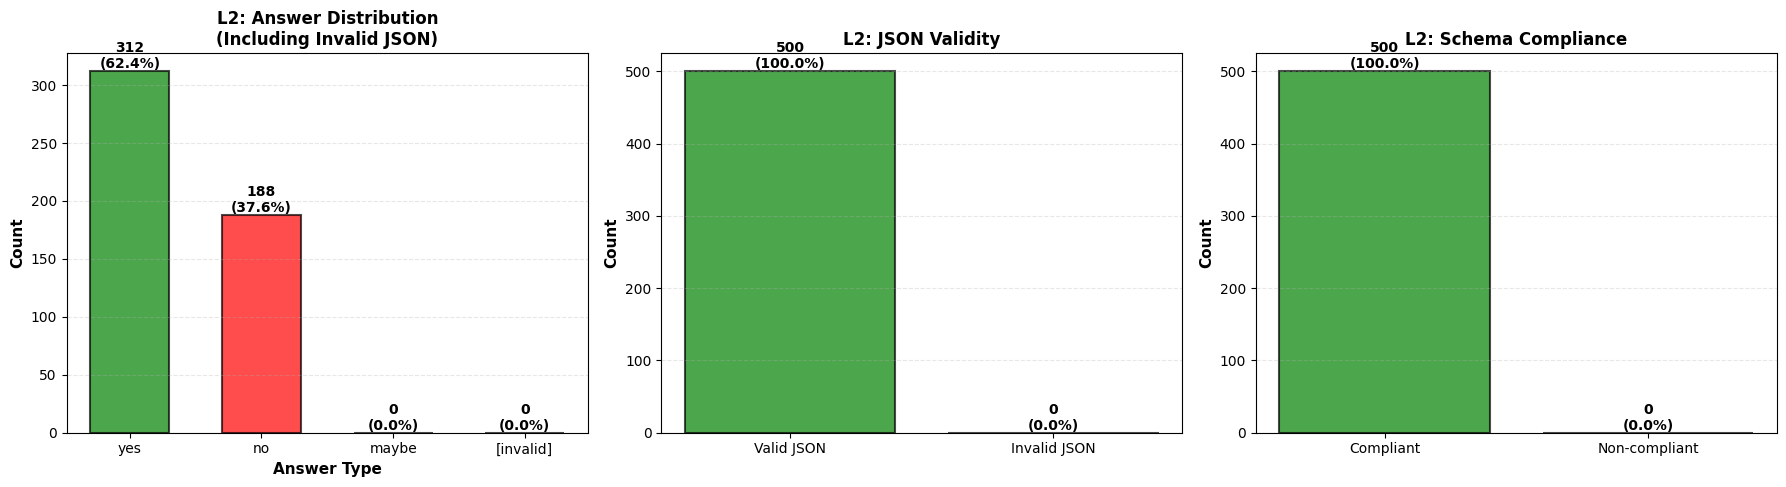

In [29]:
# Create visualizations for L2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Answer Distribution (including invalid JSON)
ax1 = axes[0]
x_pos = np.arange(len(l2_categories))
bars1 = ax1.bar(x_pos, l2_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l2_counts):
    height = bar.get_height()
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L2: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l2_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. JSON Validity
ax2 = axes[1]
valid_count = l2_valid_json_count
invalid_count = l2_total - l2_valid_json_count
bars2 = ax2.bar(['Valid JSON', 'Invalid JSON'], [valid_count, invalid_count], 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, [valid_count, invalid_count]):
    height = bar.get_height()
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L2: JSON Validity', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Schema Compliance
ax3 = axes[2]
compliant_count = l2_compliant
non_compliant_count = l2_total - l2_compliant
bars3 = ax3.bar(['Compliant', 'Non-compliant'], [compliant_count, non_compliant_count],
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars3, [compliant_count, non_compliant_count]):
    height = bar.get_height()
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('L2: Schema Compliance', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_14207/896347516.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(conf_by_type_data, labels=conf_by_type_labels, patch_artist=True)


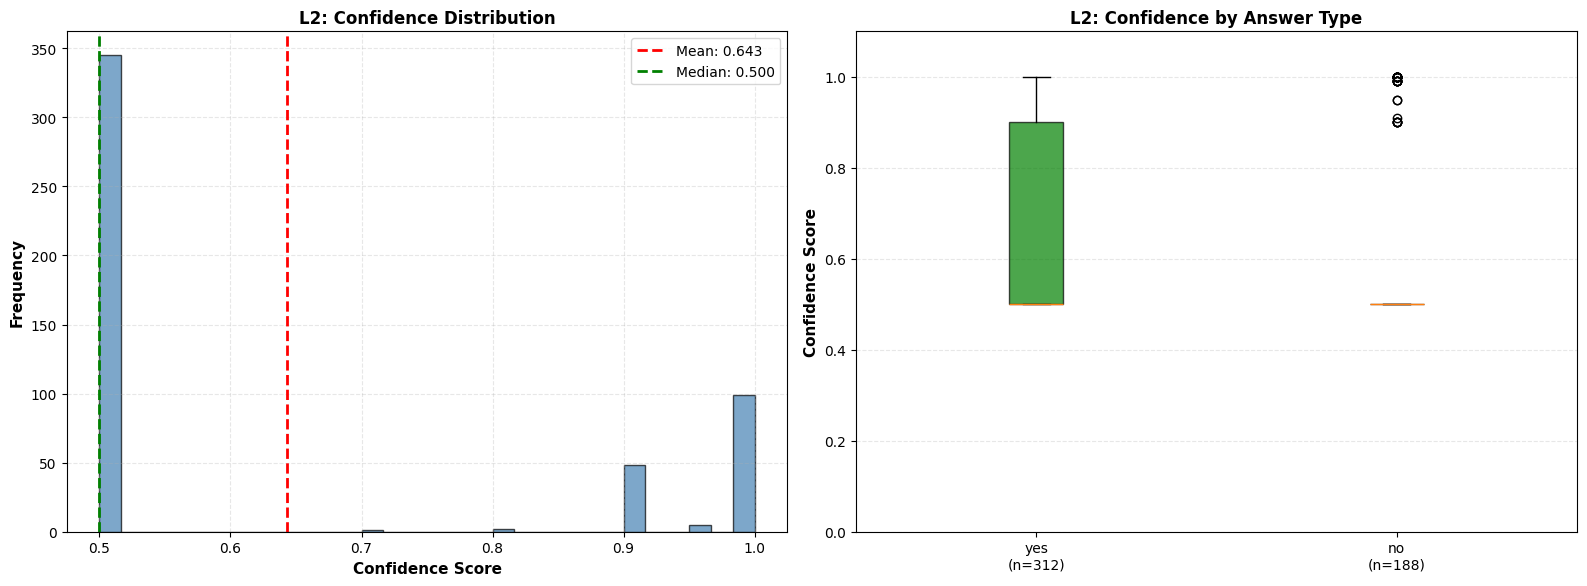

In [30]:
# Confidence Distribution Histogram and Confidence by Answer Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confidence Distribution Histogram
ax1 = axes[0]
if l2_valid_confidences:
    ax1.hist(l2_valid_confidences, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(np.mean(l2_valid_confidences), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l2_valid_confidences):.3f}')
    ax1.axvline(np.median(l2_valid_confidences), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l2_valid_confidences):.3f}')
    ax1.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax1.set_title('L2: Confidence Distribution', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3, linestyle='--')
else:
    ax1.text(0.5, 0.5, 'No valid\nconfidence scores', 
            ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('L2: Confidence Distribution', fontsize=12, fontweight='bold')
ax1.tick_params(labelsize=10)

# 2. Confidence by Answer Type
ax2 = axes[1]
conf_by_type_data = []
conf_by_type_labels = []
for answer_type in ['yes', 'no', 'maybe']:
    conf_by_type = [l2_confidences[i] for i, ans in enumerate(l2_answers) 
                   if ans == answer_type and l2_confidences[i] is not None]
    if conf_by_type:
        conf_by_type_data.append(conf_by_type)
        conf_by_type_labels.append(f'{answer_type}\n(n={len(conf_by_type)})')

if conf_by_type_data:
    bp = ax2.boxplot(conf_by_type_data, labels=conf_by_type_labels, patch_artist=True)
    colors_box = ['green', 'red', 'orange']
    for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('Confidence Score', fontsize=11, fontweight='bold')
    ax2.set_title('L2: Confidence by Answer Type', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_ylim([0, 1.1])
else:
    ax2.text(0.5, 0.5, 'No valid\nconfidence scores', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('L2: Confidence by Answer Type', fontsize=12, fontweight='bold')
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


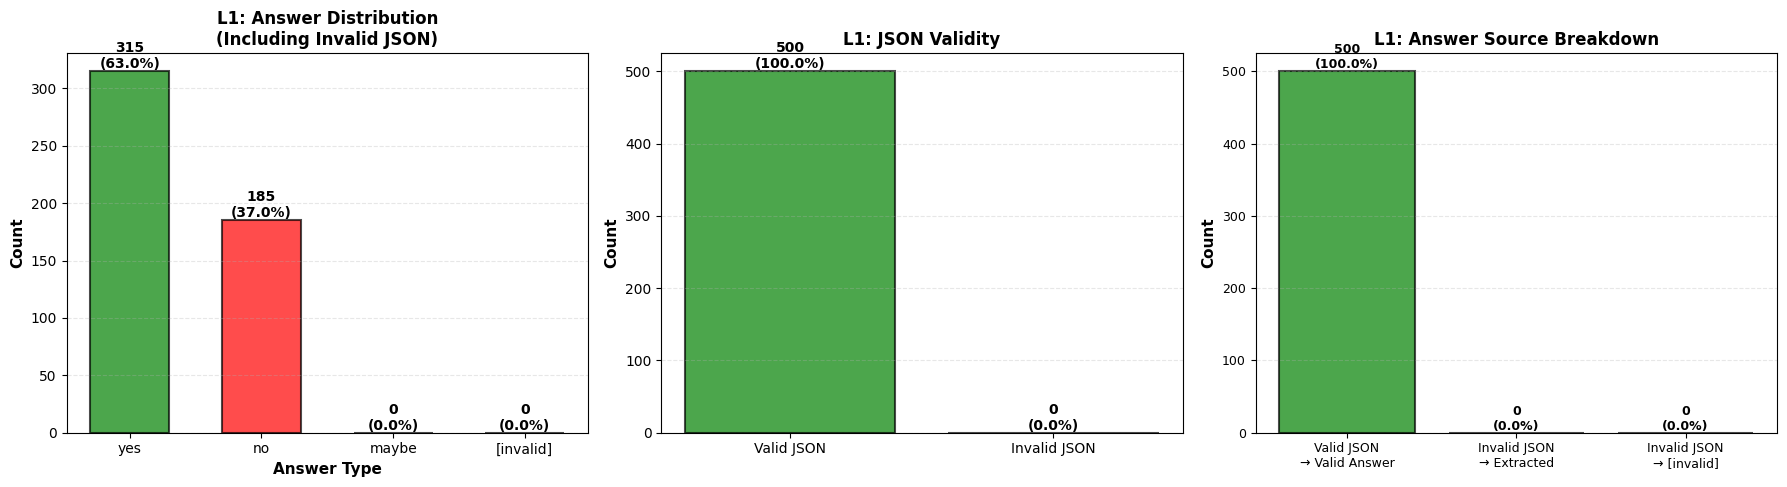

In [31]:
# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Answer Distribution (including invalid JSON)
ax1 = axes[0]
x_pos = np.arange(len(l1_categories))
bars1 = ax1.bar(x_pos, l1_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l1_counts):
    height = bar.get_height()
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L1: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l1_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. JSON Validity
ax2 = axes[1]
valid_count = l1_valid_json_count
invalid_count = l1_total - l1_valid_json_count
bars2 = ax2.bar(['Valid JSON', 'Invalid JSON'], [valid_count, invalid_count], 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, [valid_count, invalid_count]):
    height = bar.get_height()
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L1: JSON Validity', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Answer Source Breakdown
ax3 = axes[2]
# Categorize answers by source
from_valid_json = l1_compliant
from_invalid_json = sum([1 for i in range(l1_total) if not l1_valid_json[i] and l1_answers[i] != '[invalid]'])
invalid_answers = l1_counts[3]

categories_source = ['Valid JSON\n→ Valid Answer', 'Invalid JSON\n→ Extracted', 'Invalid JSON\n→ [invalid]']
counts_source = [from_valid_json, from_invalid_json, invalid_answers]
colors_source = ['green', 'orange', 'red']

bars3 = ax3.bar(categories_source, counts_source, color=colors_source, alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars3, counts_source):
    height = bar.get_height()
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('L1: Answer Source Breakdown', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


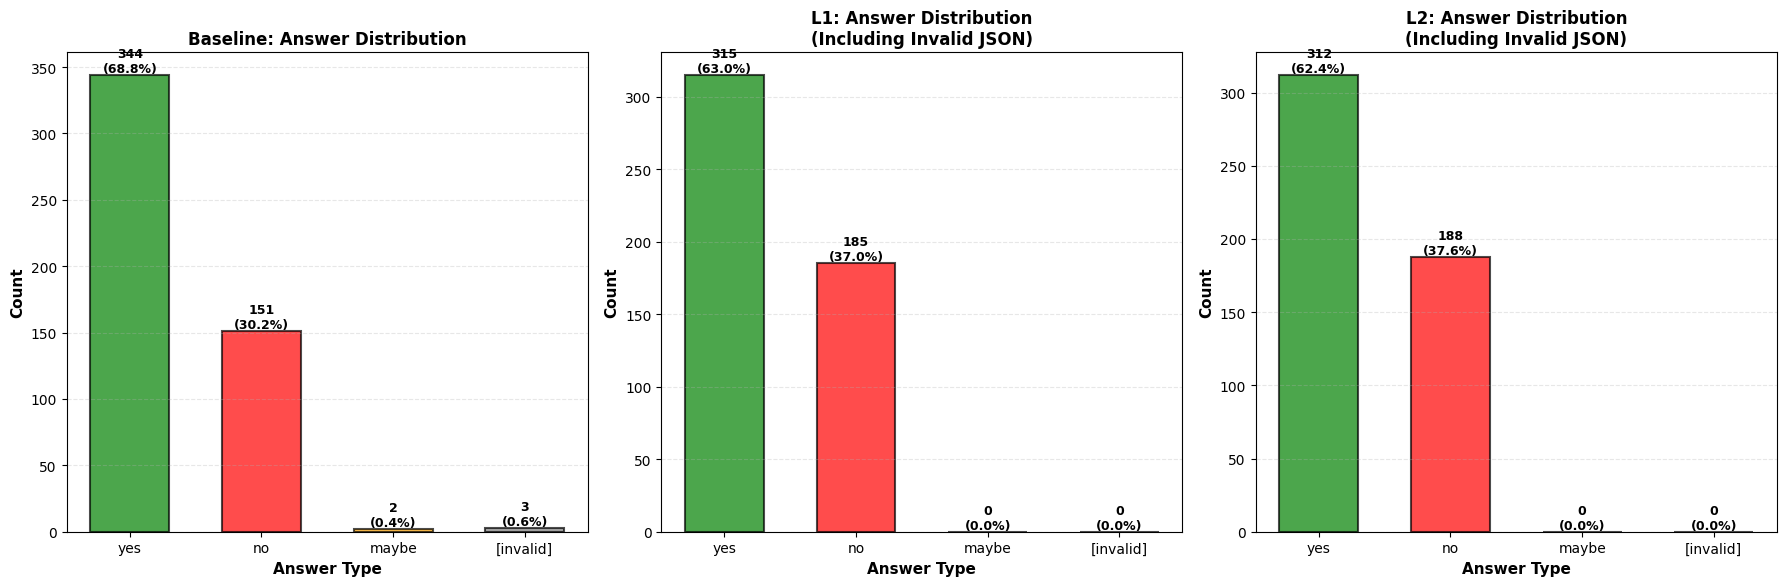

## Load L3 Results

In [32]:
# Load L3 result JSON
l3_result_file = "pubmedqa_level3_2025-12-08T16-37-05.472225.json"

with open(l3_result_file, 'r') as f:
    l3_results = json.load(f)

l3_exact_match = l3_results['results']['pubmedqa_generation']['exact_match,strict-match']
l3_exact_match_stderr = l3_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L3 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l3_exact_match:.4f} ± {l3_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l3_exact_match*100:.2f}%")
print("="*60)


L3 PERFORMANCE METRICS
Exact Match Score: 0.7720 ± 0.0188
Exact Match Percentage: 77.20%


## L3 Answer Distribution Analysis (Including Invalid JSON)


In [33]:
# Load L3 samples and extract data
l3_samples_file = "samples_pubmedqa_generation_L3.jsonl"

l3_answers = []
l3_reasonings = []
l3_reasoning_lengths = []
l3_valid_json = []
l3_has_answer = []
l3_has_reasoning = []
l3_answer_valid = []
l3_reasoning_valid = []
l3_responses = []
l3_filtered_responses = []

with open(l3_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        reasoning = None
        reasoning_length = 0
        has_answer_field = False
        has_reasoning_field = False
        answer_is_valid_enum = False
        reasoning_is_valid = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
                
                # Extract reasoning
                reasoning_val = parsed.get('reasoning')
                if reasoning_val is not None:
                    reasoning = str(reasoning_val).strip()
                    has_reasoning_field = True
                    reasoning_length = len(reasoning)
                    # L3 requires reasoning between 10-200 chars
                    reasoning_is_valid = (10 <= reasoning_length <= 200)
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l3_answers.append(answer)
        l3_reasonings.append(reasoning)
        l3_reasoning_lengths.append(reasoning_length)
        l3_valid_json.append(json_valid)
        l3_has_answer.append(has_answer_field)
        l3_has_reasoning.append(has_reasoning_field)
        l3_answer_valid.append(answer_is_valid_enum)
        l3_reasoning_valid.append(reasoning_is_valid)
        l3_responses.append(raw_resp if raw_resp else '')
        l3_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l3_answer_counts = Counter(l3_answers)
l3_categories = ['yes', 'no', 'maybe', '[invalid]']
l3_counts = [l3_answer_counts.get(cat, 0) for cat in l3_categories]

# Calculate schema compliance
l3_total = len(l3_answers)
l3_valid_json_count = sum(l3_valid_json)
l3_compliant = sum([l3_valid_json[i] and l3_has_answer[i] and l3_has_reasoning[i] 
                     and l3_answer_valid[i] and l3_reasoning_valid[i] 
                     for i in range(l3_total)])

print("="*60)
print("L3 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l3_categories, l3_counts):
    percentage = count / l3_total * 100 if l3_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l3_total}")
print(f"Valid answers (yes+no+maybe): {sum(l3_counts[:3])} ({sum(l3_counts[:3])/l3_total*100:.2f}%)")
print(f"Invalid answers: {l3_counts[3]} ({l3_counts[3]/l3_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l3_valid_json_count}/{l3_total} ({l3_valid_json_count/l3_total*100:.2f}%)")
print(f"  Invalid JSON: {l3_total - l3_valid_json_count}/{l3_total} ({(l3_total - l3_valid_json_count)/l3_total*100:.2f}%)")

print(f"\nSchema Compliance:")
print(f"  Has answer field: {sum(l3_has_answer)}/{l3_total} ({sum(l3_has_answer)/l3_total*100:.2f}%)")
print(f"  Has reasoning field: {sum(l3_has_reasoning)}/{l3_total} ({sum(l3_has_reasoning)/l3_total*100:.2f}%)")
print(f"  Answer is valid enum: {sum(l3_answer_valid)}/{l3_total} ({sum(l3_answer_valid)/l3_total*100:.2f}%)")
print(f"  Reasoning length valid (10-200 chars): {sum(l3_reasoning_valid)}/{l3_total} ({sum(l3_reasoning_valid)/l3_total*100:.2f}%)")
print(f"  Full schema compliance: {l3_compliant}/{l3_total} ({l3_compliant/l3_total*100:.2f}%)")
print("="*60)


L3 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  315 (63.00%)
  no          :  185 (37.00%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 488/500 (97.60%)
  Invalid JSON: 12/500 (2.40%)

Schema Compliance:
  Has answer field: 488/500 (97.60%)
  Has reasoning field: 488/500 (97.60%)
  Answer is valid enum: 488/500 (97.60%)
  Reasoning length valid (10-200 chars): 488/500 (97.60%)
  Full schema compliance: 488/500 (97.60%)


In [34]:
# Reasoning Length Statistics for L3
l3_valid_reasonings = [r for r in l3_reasonings if r is not None]
l3_valid_reasoning_lengths = [l3_reasoning_lengths[i] for i, r in enumerate(l3_reasonings) if r is not None]

print("="*60)
print("L3 REASONING LENGTH STATISTICS")
print("="*60)

if l3_valid_reasoning_lengths:
    print(f"Valid reasoning texts: {len(l3_valid_reasoning_lengths)} ({len(l3_valid_reasoning_lengths)/l3_total*100:.1f}%)")
    print(f"Missing/Invalid reasoning: {l3_total - len(l3_valid_reasoning_lengths)}")
    print(f"\nDescriptive Statistics (characters):")
    print(f"  Mean: {np.mean(l3_valid_reasoning_lengths):.2f}")
    print(f"  Median: {np.median(l3_valid_reasoning_lengths):.2f}")
    print(f"  Std Dev: {np.std(l3_valid_reasoning_lengths):.2f}")
    print(f"  Min: {np.min(l3_valid_reasoning_lengths):.0f}")
    print(f"  Max: {np.max(l3_valid_reasoning_lengths):.0f}")
    print(f"  Range: {np.max(l3_valid_reasoning_lengths) - np.min(l3_valid_reasoning_lengths):.0f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l3_valid_reasoning_lengths, p):.2f}")
    
    # Reasoning length by answer type
    print(f"\nReasoning Length by Answer Type:")
    for answer_type in ['yes', 'no', 'maybe']:
        lengths_by_type = [l3_reasoning_lengths[i] for i, ans in enumerate(l3_answers) 
                          if ans == answer_type and l3_reasonings[i] is not None]
        if lengths_by_type:
            print(f"  {answer_type}: mean={np.mean(lengths_by_type):.2f}, median={np.median(lengths_by_type):.2f}, count={len(lengths_by_type)}")
        else:
            print(f"  {answer_type}: No valid reasoning texts")
    
    # Count within/outside valid range
    within_range = sum([1 for l in l3_valid_reasoning_lengths if 10 <= l <= 200])
    print(f"\nReasoning Length Compliance:")
    print(f"  Within valid range (10-200 chars): {within_range}/{len(l3_valid_reasoning_lengths)} ({within_range/len(l3_valid_reasoning_lengths)*100:.2f}%)")
    print(f"  Too short (<10 chars): {sum([1 for l in l3_valid_reasoning_lengths if l < 10])}")
    print(f"  Too long (>200 chars): {sum([1 for l in l3_valid_reasoning_lengths if l > 200])}")
else:
    print("No valid reasoning texts found!")
print("="*60)


L3 REASONING LENGTH STATISTICS
Valid reasoning texts: 488 (97.6%)
Missing/Invalid reasoning: 12

Descriptive Statistics (characters):
  Mean: 197.27
  Median: 200.00
  Std Dev: 12.20
  Min: 80
  Max: 200
  Range: 120

Percentiles:
  25th: 199.00
  50th: 200.00
  75th: 200.00
  90th: 200.00
  95th: 200.00

Reasoning Length by Answer Type:
  yes: mean=197.91, median=200.00, count=306
  no: mean=196.18, median=200.00, count=182
  maybe: No valid reasoning texts

Reasoning Length Compliance:
  Within valid range (10-200 chars): 488/488 (100.00%)
  Too short (<10 chars): 0
  Too long (>200 chars): 0


## L3 Visualizations


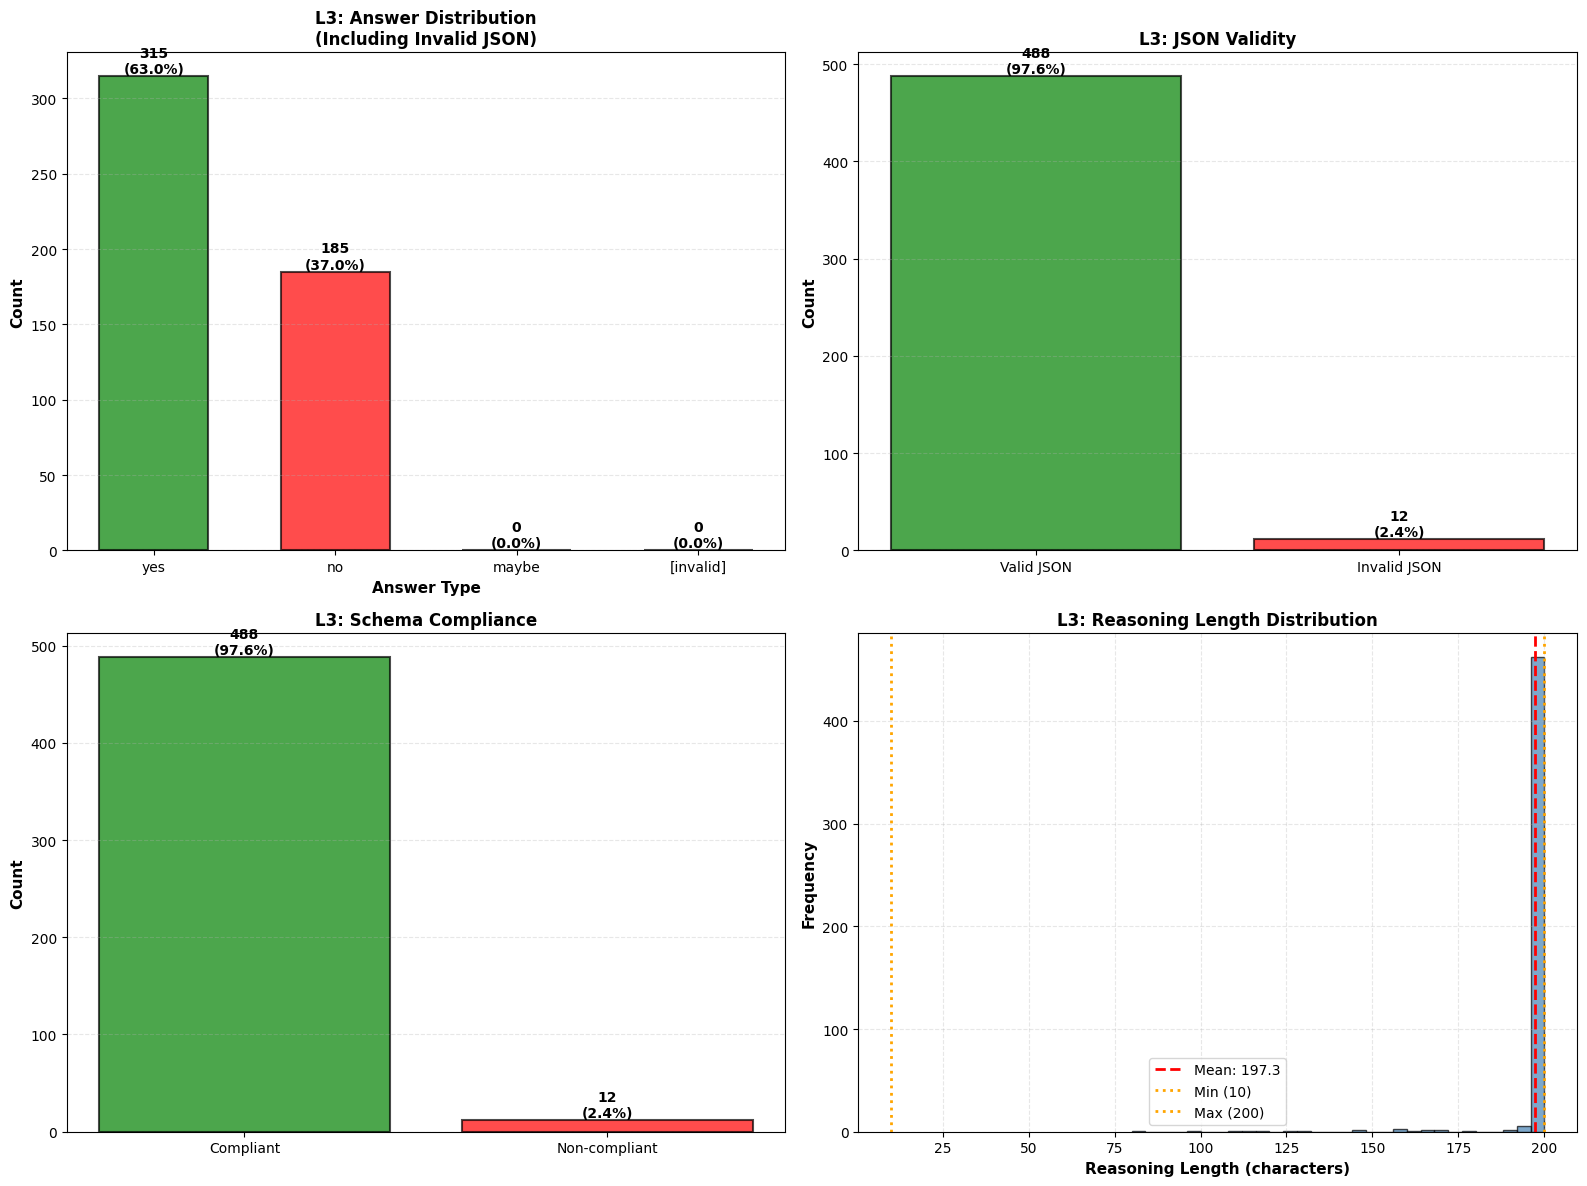

In [35]:
# Create visualizations for L3
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Answer Distribution
ax1 = axes[0, 0]
x_pos = np.arange(len(l3_categories))
bars1 = ax1.bar(x_pos, l3_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l3_counts):
    height = bar.get_height()
    percentage = count / l3_total * 100 if l3_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L3: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l3_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. JSON Validity
ax2 = axes[0, 1]
valid_count = l3_valid_json_count
invalid_count = l3_total - l3_valid_json_count
bars2 = ax2.bar(['Valid JSON', 'Invalid JSON'], [valid_count, invalid_count], 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, [valid_count, invalid_count]):
    height = bar.get_height()
    percentage = count / l3_total * 100 if l3_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L3: JSON Validity', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Schema Compliance
ax3 = axes[1, 0]
compliant_count = l3_compliant
non_compliant_count = l3_total - l3_compliant
bars3 = ax3.bar(['Compliant', 'Non-compliant'], [compliant_count, non_compliant_count],
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars3, [compliant_count, non_compliant_count]):
    height = bar.get_height()
    percentage = count / l3_total * 100 if l3_total > 0 else 0
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('L3: Schema Compliance', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.tick_params(labelsize=10)

# 4. Reasoning Length Histogram
ax4 = axes[1, 1]
if l3_valid_reasoning_lengths:
    ax4.hist(l3_valid_reasoning_lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax4.axvline(np.mean(l3_valid_reasoning_lengths), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l3_valid_reasoning_lengths):.1f}')
    ax4.axvline(10, color='orange', linestyle=':', linewidth=2, label='Min (10)')
    ax4.axvline(200, color='orange', linestyle=':', linewidth=2, label='Max (200)')
    ax4.set_xlabel('Reasoning Length (characters)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax4.set_title('L3: Reasoning Length Distribution', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3, linestyle='--')
else:
    ax4.text(0.5, 0.5, 'No valid\nreasoning texts', 
            ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('L3: Reasoning Length Distribution', fontsize=12, fontweight='bold')
ax4.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Load L4 Results


In [36]:
# Load L4 result JSON
l4_result_file = "pubmedqa_level4_2025-12-08T17-53-41.436382.json"

with open(l4_result_file, 'r') as f:
    l4_results = json.load(f)

l4_exact_match = l4_results['results']['pubmedqa_generation']['exact_match,strict-match']
l4_exact_match_stderr = l4_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L4 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l4_exact_match:.4f} ± {l4_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l4_exact_match*100:.2f}%")
print("="*60)


L4 PERFORMANCE METRICS
Exact Match Score: 0.7740 ± 0.0187
Exact Match Percentage: 77.40%


## L4 Answer Distribution Analysis (Including Invalid JSON)


In [37]:
# Load L4 samples and extract data
l4_samples_file = "samples_pubmedqa_generation_L4.jsonl"

l4_answers = []
l4_confidences = []
l4_reasonings = []
l4_reasoning_lengths = []
l4_valid_json = []
l4_has_answer = []
l4_has_confidence = []
l4_has_reasoning = []
l4_answer_valid = []
l4_confidence_valid = []
l4_reasoning_valid = []
l4_responses = []
l4_filtered_responses = []

with open(l4_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        confidence = None
        reasoning = None
        reasoning_length = 0
        has_answer_field = False
        has_confidence_field = False
        has_reasoning_field = False
        answer_is_valid_enum = False
        confidence_is_valid = False
        reasoning_is_valid = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
                
                # Extract confidence
                confidence_val = parsed.get('confidence')
                if confidence_val is not None:
                    try:
                        confidence = float(confidence_val)
                        has_confidence_field = True
                        confidence_is_valid = (0.0 <= confidence <= 1.0)
                    except (ValueError, TypeError):
                        confidence = None
                        has_confidence_field = False
                        confidence_is_valid = False
                
                # Extract reasoning
                reasoning_val = parsed.get('reasoning')
                if reasoning_val is not None:
                    reasoning = str(reasoning_val).strip()
                    has_reasoning_field = True
                    reasoning_length = len(reasoning)
                    # L4 requires reasoning between 10-200 chars
                    reasoning_is_valid = (10 <= reasoning_length <= 200)
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l4_answers.append(answer)
        l4_confidences.append(confidence)
        l4_reasonings.append(reasoning)
        l4_reasoning_lengths.append(reasoning_length)
        l4_valid_json.append(json_valid)
        l4_has_answer.append(has_answer_field)
        l4_has_confidence.append(has_confidence_field)
        l4_has_reasoning.append(has_reasoning_field)
        l4_answer_valid.append(answer_is_valid_enum)
        l4_confidence_valid.append(confidence_is_valid)
        l4_reasoning_valid.append(reasoning_is_valid)
        l4_responses.append(raw_resp if raw_resp else '')
        l4_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l4_answer_counts = Counter(l4_answers)
l4_categories = ['yes', 'no', 'maybe', '[invalid]']
l4_counts = [l4_answer_counts.get(cat, 0) for cat in l4_categories]

# Calculate schema compliance
l4_total = len(l4_answers)
l4_valid_json_count = sum(l4_valid_json)
l4_compliant = sum([l4_valid_json[i] and l4_has_answer[i] and l4_has_confidence[i] and l4_has_reasoning[i]
                     and l4_answer_valid[i] and l4_confidence_valid[i] and l4_reasoning_valid[i] 
                     for i in range(l4_total)])

print("="*60)
print("L4 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l4_categories, l4_counts):
    percentage = count / l4_total * 100 if l4_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l4_total}")
print(f"Valid answers (yes+no+maybe): {sum(l4_counts[:3])} ({sum(l4_counts[:3])/l4_total*100:.2f}%)")
print(f"Invalid answers: {l4_counts[3]} ({l4_counts[3]/l4_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l4_valid_json_count}/{l4_total} ({l4_valid_json_count/l4_total*100:.2f}%)")
print(f"  Invalid JSON: {l4_total - l4_valid_json_count}/{l4_total} ({(l4_total - l4_valid_json_count)/l4_total*100:.2f}%)")

print(f"\nSchema Compliance:")
print(f"  Has answer field: {sum(l4_has_answer)}/{l4_total} ({sum(l4_has_answer)/l4_total*100:.2f}%)")
print(f"  Has confidence field: {sum(l4_has_confidence)}/{l4_total} ({sum(l4_has_confidence)/l4_total*100:.2f}%)")
print(f"  Has reasoning field: {sum(l4_has_reasoning)}/{l4_total} ({sum(l4_has_reasoning)/l4_total*100:.2f}%)")
print(f"  Answer is valid enum: {sum(l4_answer_valid)}/{l4_total} ({sum(l4_answer_valid)/l4_total*100:.2f}%)")
print(f"  Confidence in range [0.0, 1.0]: {sum(l4_confidence_valid)}/{l4_total} ({sum(l4_confidence_valid)/l4_total*100:.2f}%)")
print(f"  Reasoning length valid (10-200 chars): {sum(l4_reasoning_valid)}/{l4_total} ({sum(l4_reasoning_valid)/l4_total*100:.2f}%)")
print(f"  Full schema compliance: {l4_compliant}/{l4_total} ({l4_compliant/l4_total*100:.2f}%)")
print("="*60)


L4 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  312 (62.40%)
  no          :  188 (37.60%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 479/500 (95.80%)
  Invalid JSON: 21/500 (4.20%)

Schema Compliance:
  Has answer field: 479/500 (95.80%)
  Has confidence field: 479/500 (95.80%)
  Has reasoning field: 479/500 (95.80%)
  Answer is valid enum: 479/500 (95.80%)
  Confidence in range [0.0, 1.0]: 479/500 (95.80%)
  Reasoning length valid (10-200 chars): 479/500 (95.80%)
  Full schema compliance: 479/500 (95.80%)


In [38]:
# Confidence and Reasoning Statistics for L4
l4_valid_confidences = [c for c in l4_confidences if c is not None]
l4_valid_reasoning_lengths = [l4_reasoning_lengths[i] for i, r in enumerate(l4_reasonings) if r is not None]

print("="*60)
print("L4 CONFIDENCE SCORE STATISTICS")
print("="*60)

if l4_valid_confidences:
    print(f"Valid confidence scores: {len(l4_valid_confidences)} ({len(l4_valid_confidences)/l4_total*100:.1f}%)")
    print(f"Missing/Invalid confidence: {l4_total - len(l4_valid_confidences)}")
    print(f"\nDescriptive Statistics:")
    print(f"  Mean: {np.mean(l4_valid_confidences):.4f}")
    print(f"  Median: {np.median(l4_valid_confidences):.4f}")
    print(f"  Std Dev: {np.std(l4_valid_confidences):.4f}")
    print(f"  Min: {np.min(l4_valid_confidences):.4f}")
    print(f"  Max: {np.max(l4_valid_confidences):.4f}")
    print(f"  Range: {np.max(l4_valid_confidences) - np.min(l4_valid_confidences):.4f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l4_valid_confidences, p):.4f}")
    
    # Confidence by answer type
    print(f"\nConfidence by Answer Type:")
    for answer_type in ['yes', 'no', 'maybe']:
        conf_by_type = [l4_confidences[i] for i, ans in enumerate(l4_answers) 
                       if ans == answer_type and l4_confidences[i] is not None]
        if conf_by_type:
            print(f"  {answer_type}: mean={np.mean(conf_by_type):.4f}, median={np.median(conf_by_type):.4f}, count={len(conf_by_type)}")
        else:
            print(f"  {answer_type}: No valid confidence scores")
else:
    print("No valid confidence scores found!")

print("\n" + "="*60)
print("L4 REASONING LENGTH STATISTICS")
print("="*60)

if l4_valid_reasoning_lengths:
    print(f"Valid reasoning texts: {len(l4_valid_reasoning_lengths)} ({len(l4_valid_reasoning_lengths)/l4_total*100:.1f}%)")
    print(f"Missing/Invalid reasoning: {l4_total - len(l4_valid_reasoning_lengths)}")
    print(f"\nDescriptive Statistics (characters):")
    print(f"  Mean: {np.mean(l4_valid_reasoning_lengths):.2f}")
    print(f"  Median: {np.median(l4_valid_reasoning_lengths):.2f}")
    print(f"  Std Dev: {np.std(l4_valid_reasoning_lengths):.2f}")
    print(f"  Min: {np.min(l4_valid_reasoning_lengths):.0f}")
    print(f"  Max: {np.max(l4_valid_reasoning_lengths):.0f}")
    print(f"  Range: {np.max(l4_valid_reasoning_lengths) - np.min(l4_valid_reasoning_lengths):.0f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l4_valid_reasoning_lengths, p):.2f}")
    
    # Count within/outside valid range
    within_range = sum([1 for l in l4_valid_reasoning_lengths if 10 <= l <= 200])
    print(f"\nReasoning Length Compliance:")
    print(f"  Within valid range (10-200 chars): {within_range}/{len(l4_valid_reasoning_lengths)} ({within_range/len(l4_valid_reasoning_lengths)*100:.2f}%)")
    print(f"  Too short (<10 chars): {sum([1 for l in l4_valid_reasoning_lengths if l < 10])}")
    print(f"  Too long (>200 chars): {sum([1 for l in l4_valid_reasoning_lengths if l > 200])}")
else:
    print("No valid reasoning texts found!")
print("="*60)


L4 CONFIDENCE SCORE STATISTICS
Valid confidence scores: 479 (95.8%)
Missing/Invalid confidence: 21

Descriptive Statistics:
  Mean: 0.7276
  Median: 0.9000
  Std Dev: 0.2013
  Min: 0.0000
  Max: 1.0000
  Range: 1.0000

Percentiles:
  25th: 0.5000
  50th: 0.9000
  75th: 0.9000
  90th: 0.9000
  95th: 0.9500

Confidence by Answer Type:
  yes: mean=0.7686, median=0.9000, count=298
  no: mean=0.6601, median=0.5000, count=181
  maybe: No valid confidence scores

L4 REASONING LENGTH STATISTICS
Valid reasoning texts: 479 (95.8%)
Missing/Invalid reasoning: 21

Descriptive Statistics (characters):
  Mean: 197.11
  Median: 200.00
  Std Dev: 12.56
  Min: 80
  Max: 200
  Range: 120

Percentiles:
  25th: 199.00
  50th: 200.00
  75th: 200.00
  90th: 200.00
  95th: 200.00

Reasoning Length Compliance:
  Within valid range (10-200 chars): 479/479 (100.00%)
  Too short (<10 chars): 0
  Too long (>200 chars): 0


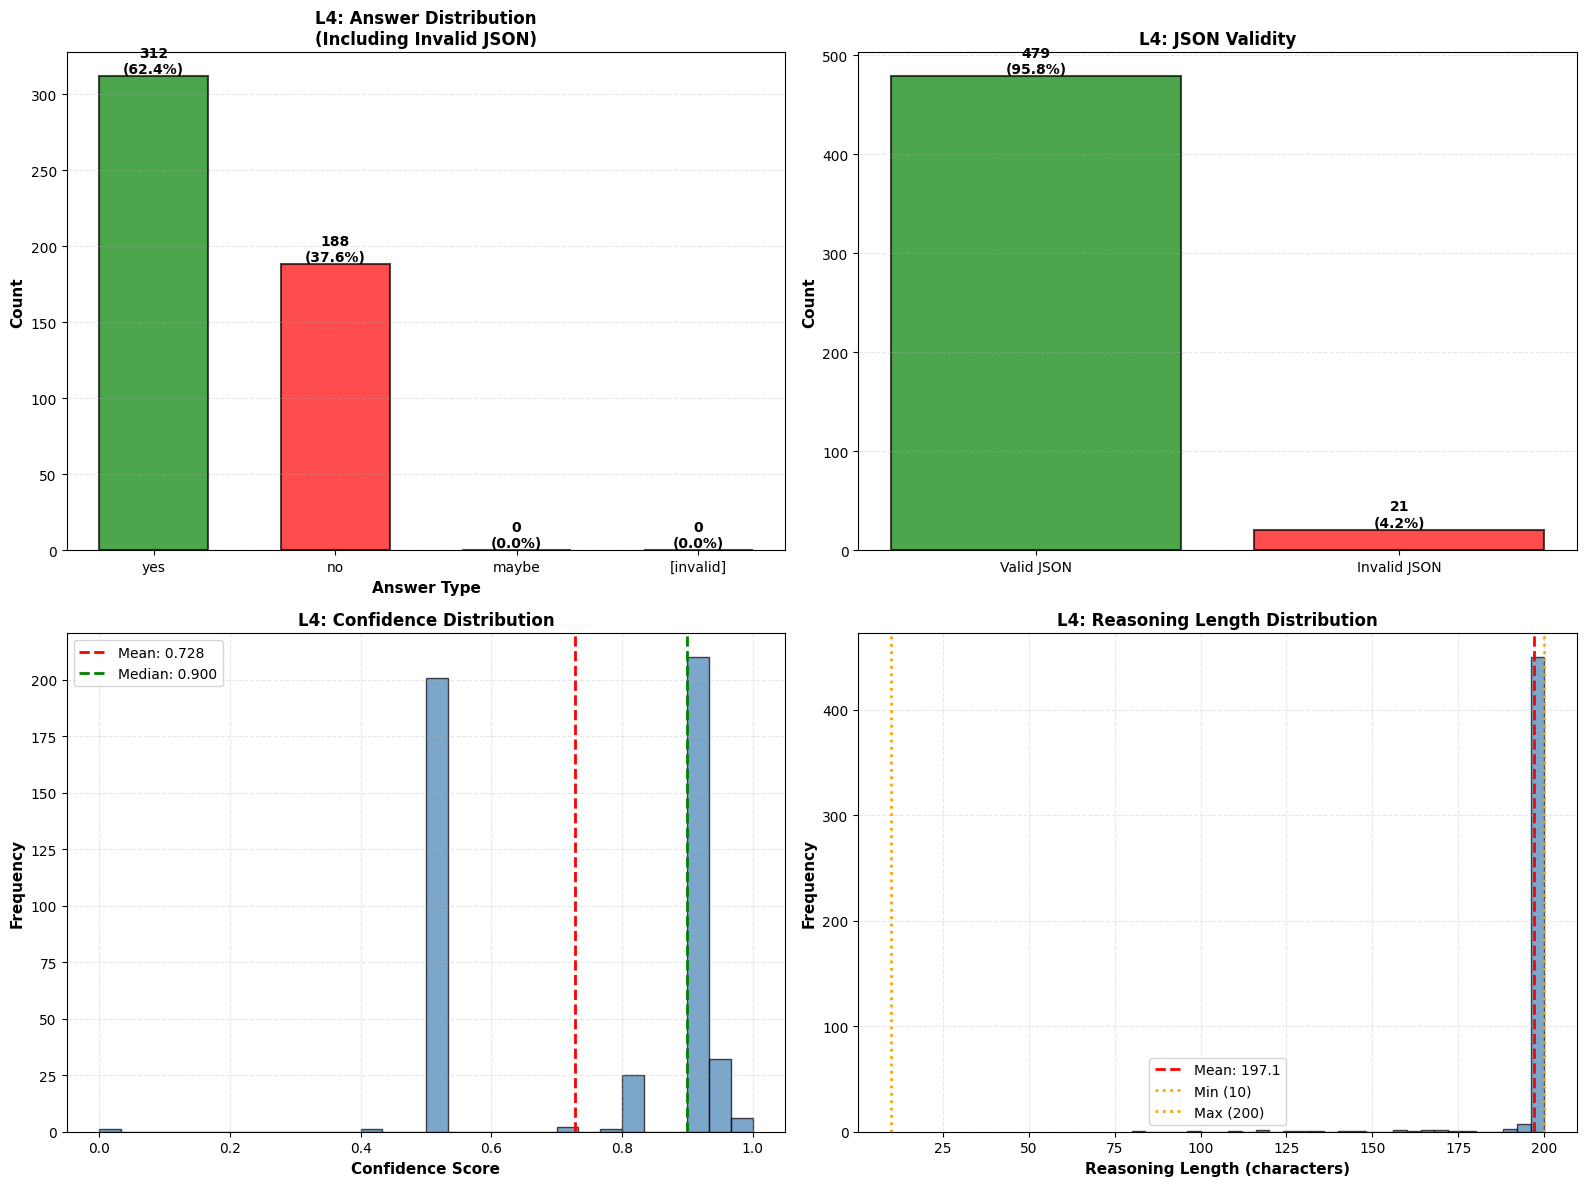

In [39]:
# Create visualizations for L4
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Answer Distribution
ax1 = axes[0, 0]
x_pos = np.arange(len(l4_categories))
bars1 = ax1.bar(x_pos, l4_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l4_counts):
    height = bar.get_height()
    percentage = count / l4_total * 100 if l4_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L4: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l4_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. JSON Validity
ax2 = axes[0, 1]
valid_count = l4_valid_json_count
invalid_count = l4_total - l4_valid_json_count
bars2 = ax2.bar(['Valid JSON', 'Invalid JSON'], [valid_count, invalid_count], 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, [valid_count, invalid_count]):
    height = bar.get_height()
    percentage = count / l4_total * 100 if l4_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L4: JSON Validity', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Confidence Distribution Histogram
ax3 = axes[1, 0]
if l4_valid_confidences:
    ax3.hist(l4_valid_confidences, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(np.mean(l4_valid_confidences), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l4_valid_confidences):.3f}')
    ax3.axvline(np.median(l4_valid_confidences), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l4_valid_confidences):.3f}')
    ax3.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax3.set_title('L4: Confidence Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3, linestyle='--')
else:
    ax3.text(0.5, 0.5, 'No valid\nconfidence scores', 
            ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('L4: Confidence Distribution', fontsize=12, fontweight='bold')
ax3.tick_params(labelsize=10)

# 4. Reasoning Length Histogram
ax4 = axes[1, 1]
if l4_valid_reasoning_lengths:
    ax4.hist(l4_valid_reasoning_lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax4.axvline(np.mean(l4_valid_reasoning_lengths), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l4_valid_reasoning_lengths):.1f}')
    ax4.axvline(10, color='orange', linestyle=':', linewidth=2, label='Min (10)')
    ax4.axvline(200, color='orange', linestyle=':', linewidth=2, label='Max (200)')
    ax4.set_xlabel('Reasoning Length (characters)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax4.set_title('L4: Reasoning Length Distribution', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3, linestyle='--')
else:
    ax4.text(0.5, 0.5, 'No valid\nreasoning texts', 
            ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('L4: Reasoning Length Distribution', fontsize=12, fontweight='bold')
ax4.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Load L5 Results


In [40]:
# Load L5 result JSON
l5_result_file = "pubmedqa_level5_2025-12-08T19-23-52.009458.json"

with open(l5_result_file, 'r') as f:
    l5_results = json.load(f)

l5_exact_match = l5_results['results']['pubmedqa_generation']['exact_match,strict-match']
l5_exact_match_stderr = l5_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L5 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l5_exact_match:.4f} ± {l5_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l5_exact_match*100:.2f}%")
print("="*60)


L5 PERFORMANCE METRICS
Exact Match Score: 0.7740 ± 0.0187
Exact Match Percentage: 77.40%


## L5 Answer Distribution Analysis (Including Invalid JSON)


In [41]:
# Load L5 samples and extract data
l5_samples_file = "samples_pubmedqa_generation_L5.jsonl"

l5_answers = []
l5_confidences = []
l5_reasonings = []
l5_reasoning_lengths = []
l5_key_evidence = []
l5_key_evidence_counts = []
l5_key_evidence_lengths = []
l5_valid_json = []
l5_has_answer = []
l5_has_confidence = []
l5_has_reasoning = []
l5_has_key_evidence = []
l5_answer_valid = []
l5_confidence_valid = []
l5_reasoning_valid = []
l5_key_evidence_valid = []
l5_responses = []
l5_filtered_responses = []

with open(l5_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        confidence = None
        reasoning = None
        reasoning_length = 0
        key_evidence_list = None
        key_evidence_count = 0
        key_evidence_total_length = 0
        has_answer_field = False
        has_confidence_field = False
        has_reasoning_field = False
        has_key_evidence_field = False
        answer_is_valid_enum = False
        confidence_is_valid = False
        reasoning_is_valid = False
        key_evidence_is_valid = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
                
                # Extract confidence
                confidence_val = parsed.get('confidence')
                if confidence_val is not None:
                    try:
                        confidence = float(confidence_val)
                        has_confidence_field = True
                        confidence_is_valid = (0.0 <= confidence <= 1.0)
                    except (ValueError, TypeError):
                        confidence = None
                        has_confidence_field = False
                        confidence_is_valid = False
                
                # Extract reasoning
                reasoning_val = parsed.get('reasoning')
                if reasoning_val is not None:
                    reasoning = str(reasoning_val).strip()
                    has_reasoning_field = True
                    reasoning_length = len(reasoning)
                    # L5 requires reasoning between 10-500 chars
                    reasoning_is_valid = (10 <= reasoning_length <= 500)
                
                # Extract key_evidence
                key_evidence_val = parsed.get('key_evidence')
                if key_evidence_val is not None:
                    if isinstance(key_evidence_val, list):
                        key_evidence_list = key_evidence_val
                        has_key_evidence_field = True
                        key_evidence_count = len(key_evidence_list)
                        # L5 requires 1-5 items
                        key_evidence_is_valid = (1 <= key_evidence_count <= 5)
                        # Calculate total length of all evidence items
                        key_evidence_total_length = sum([len(str(item)) for item in key_evidence_list])
                    else:
                        key_evidence_list = None
                        has_key_evidence_field = False
                        key_evidence_is_valid = False
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l5_answers.append(answer)
        l5_confidences.append(confidence)
        l5_reasonings.append(reasoning)
        l5_reasoning_lengths.append(reasoning_length)
        l5_key_evidence.append(key_evidence_list)
        l5_key_evidence_counts.append(key_evidence_count)
        l5_key_evidence_lengths.append(key_evidence_total_length)
        l5_valid_json.append(json_valid)
        l5_has_answer.append(has_answer_field)
        l5_has_confidence.append(has_confidence_field)
        l5_has_reasoning.append(has_reasoning_field)
        l5_has_key_evidence.append(has_key_evidence_field)
        l5_answer_valid.append(answer_is_valid_enum)
        l5_confidence_valid.append(confidence_is_valid)
        l5_reasoning_valid.append(reasoning_is_valid)
        l5_key_evidence_valid.append(key_evidence_is_valid)
        l5_responses.append(raw_resp if raw_resp else '')
        l5_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l5_answer_counts = Counter(l5_answers)
l5_categories = ['yes', 'no', 'maybe', '[invalid]']
l5_counts = [l5_answer_counts.get(cat, 0) for cat in l5_categories]

# Calculate schema compliance
l5_total = len(l5_answers)
l5_valid_json_count = sum(l5_valid_json)
l5_compliant = sum([l5_valid_json[i] and l5_has_answer[i] and l5_has_confidence[i] and l5_has_reasoning[i] and l5_has_key_evidence[i]
                     and l5_answer_valid[i] and l5_confidence_valid[i] and l5_reasoning_valid[i] and l5_key_evidence_valid[i] 
                     for i in range(l5_total)])

print("="*60)
print("L5 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l5_categories, l5_counts):
    percentage = count / l5_total * 100 if l5_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l5_total}")
print(f"Valid answers (yes+no+maybe): {sum(l5_counts[:3])} ({sum(l5_counts[:3])/l5_total*100:.2f}%)")
print(f"Invalid answers: {l5_counts[3]} ({l5_counts[3]/l5_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l5_valid_json_count}/{l5_total} ({l5_valid_json_count/l5_total*100:.2f}%)")
print(f"  Invalid JSON: {l5_total - l5_valid_json_count}/{l5_total} ({(l5_total - l5_valid_json_count)/l5_total*100:.2f}%)")

print(f"\nSchema Compliance:")
print(f"  Has answer field: {sum(l5_has_answer)}/{l5_total} ({sum(l5_has_answer)/l5_total*100:.2f}%)")
print(f"  Has confidence field: {sum(l5_has_confidence)}/{l5_total} ({sum(l5_has_confidence)/l5_total*100:.2f}%)")
print(f"  Has reasoning field: {sum(l5_has_reasoning)}/{l5_total} ({sum(l5_has_reasoning)/l5_total*100:.2f}%)")
print(f"  Has key_evidence field: {sum(l5_has_key_evidence)}/{l5_total} ({sum(l5_has_key_evidence)/l5_total*100:.2f}%)")
print(f"  Answer is valid enum: {sum(l5_answer_valid)}/{l5_total} ({sum(l5_answer_valid)/l5_total*100:.2f}%)")
print(f"  Confidence in range [0.0, 1.0]: {sum(l5_confidence_valid)}/{l5_total} ({sum(l5_confidence_valid)/l5_total*100:.2f}%)")
print(f"  Reasoning length valid (10-500 chars): {sum(l5_reasoning_valid)}/{l5_total} ({sum(l5_reasoning_valid)/l5_total*100:.2f}%)")
print(f"  Key evidence count valid (1-5 items): {sum(l5_key_evidence_valid)}/{l5_total} ({sum(l5_key_evidence_valid)/l5_total*100:.2f}%)")
print(f"  Full schema compliance: {l5_compliant}/{l5_total} ({l5_compliant/l5_total*100:.2f}%)")
print("="*60)


L5 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  314 (62.80%)
  no          :  186 (37.20%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 474/500 (94.80%)
  Invalid JSON: 26/500 (5.20%)

Schema Compliance:
  Has answer field: 474/500 (94.80%)
  Has confidence field: 474/500 (94.80%)
  Has reasoning field: 474/500 (94.80%)
  Has key_evidence field: 474/500 (94.80%)
  Answer is valid enum: 474/500 (94.80%)
  Confidence in range [0.0, 1.0]: 474/500 (94.80%)
  Reasoning length valid (10-500 chars): 474/500 (94.80%)
  Key evidence count valid (1-5 items): 474/500 (94.80%)
  Full schema compliance: 474/500 (94.80%)


In [42]:
# Statistics for L5
l5_valid_confidences = [c for c in l5_confidences if c is not None]
l5_valid_reasoning_lengths = [l5_reasoning_lengths[i] for i, r in enumerate(l5_reasonings) if r is not None]
l5_valid_key_evidence_counts = [l5_key_evidence_counts[i] for i, ke in enumerate(l5_key_evidence) if ke is not None]
l5_valid_key_evidence_lengths = [l5_key_evidence_lengths[i] for i, ke in enumerate(l5_key_evidence) if ke is not None]

print("="*60)
print("L5 CONFIDENCE SCORE STATISTICS")
print("="*60)

if l5_valid_confidences:
    print(f"Valid confidence scores: {len(l5_valid_confidences)} ({len(l5_valid_confidences)/l5_total*100:.1f}%)")
    print(f"Missing/Invalid confidence: {l5_total - len(l5_valid_confidences)}")
    print(f"\nDescriptive Statistics:")
    print(f"  Mean: {np.mean(l5_valid_confidences):.4f}")
    print(f"  Median: {np.median(l5_valid_confidences):.4f}")
    print(f"  Std Dev: {np.std(l5_valid_confidences):.4f}")
    print(f"  Min: {np.min(l5_valid_confidences):.4f}")
    print(f"  Max: {np.max(l5_valid_confidences):.4f}")
    print(f"  Range: {np.max(l5_valid_confidences) - np.min(l5_valid_confidences):.4f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l5_valid_confidences, p):.4f}")
    
    # Confidence by answer type
    print(f"\nConfidence by Answer Type:")
    for answer_type in ['yes', 'no', 'maybe']:
        conf_by_type = [l5_confidences[i] for i, ans in enumerate(l5_answers) 
                       if ans == answer_type and l5_confidences[i] is not None]
        if conf_by_type:
            print(f"  {answer_type}: mean={np.mean(conf_by_type):.4f}, median={np.median(conf_by_type):.4f}, count={len(conf_by_type)}")
        else:
            print(f"  {answer_type}: No valid confidence scores")
else:
    print("No valid confidence scores found!")

print("\n" + "="*60)
print("L5 REASONING LENGTH STATISTICS")
print("="*60)

if l5_valid_reasoning_lengths:
    print(f"Valid reasoning texts: {len(l5_valid_reasoning_lengths)} ({len(l5_valid_reasoning_lengths)/l5_total*100:.1f}%)")
    print(f"Missing/Invalid reasoning: {l5_total - len(l5_valid_reasoning_lengths)}")
    print(f"\nDescriptive Statistics (characters):")
    print(f"  Mean: {np.mean(l5_valid_reasoning_lengths):.2f}")
    print(f"  Median: {np.median(l5_valid_reasoning_lengths):.2f}")
    print(f"  Std Dev: {np.std(l5_valid_reasoning_lengths):.2f}")
    print(f"  Min: {np.min(l5_valid_reasoning_lengths):.0f}")
    print(f"  Max: {np.max(l5_valid_reasoning_lengths):.0f}")
    print(f"  Range: {np.max(l5_valid_reasoning_lengths) - np.min(l5_valid_reasoning_lengths):.0f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l5_valid_reasoning_lengths, p):.2f}")
    
    # Count within/outside valid range
    within_range = sum([1 for l in l5_valid_reasoning_lengths if 10 <= l <= 500])
    print(f"\nReasoning Length Compliance:")
    print(f"  Within valid range (10-500 chars): {within_range}/{len(l5_valid_reasoning_lengths)} ({within_range/len(l5_valid_reasoning_lengths)*100:.2f}%)")
    print(f"  Too short (<10 chars): {sum([1 for l in l5_valid_reasoning_lengths if l < 10])}")
    print(f"  Too long (>500 chars): {sum([1 for l in l5_valid_reasoning_lengths if l > 500])}")
else:
    print("No valid reasoning texts found!")

print("\n" + "="*60)
print("L5 KEY EVIDENCE STATISTICS")
print("="*60)

if l5_valid_key_evidence_counts:
    print(f"Valid key_evidence lists: {len(l5_valid_key_evidence_counts)} ({len(l5_valid_key_evidence_counts)/l5_total*100:.1f}%)")
    print(f"Missing/Invalid key_evidence: {l5_total - len(l5_valid_key_evidence_counts)}")
    print(f"\nEvidence Count Statistics (items per sample):")
    print(f"  Mean: {np.mean(l5_valid_key_evidence_counts):.2f}")
    print(f"  Median: {np.median(l5_valid_key_evidence_counts):.2f}")
    print(f"  Std Dev: {np.std(l5_valid_key_evidence_counts):.2f}")
    print(f"  Min: {np.min(l5_valid_key_evidence_counts):.0f}")
    print(f"  Max: {np.max(l5_valid_key_evidence_counts):.0f}")
    print(f"  Range: {np.max(l5_valid_key_evidence_counts) - np.min(l5_valid_key_evidence_counts):.0f}")
    print(f"\nEvidence Count Distribution:")
    count_dist = Counter(l5_valid_key_evidence_counts)
    for count_val in sorted(count_dist.keys()):
        print(f"  {count_val} item(s): {count_dist[count_val]} samples ({count_dist[count_val]/len(l5_valid_key_evidence_counts)*100:.1f}%)")
    
    print(f"\nEvidence Total Length Statistics (characters per sample):")
    print(f"  Mean: {np.mean(l5_valid_key_evidence_lengths):.2f}")
    print(f"  Median: {np.median(l5_valid_key_evidence_lengths):.2f}")
    print(f"  Std Dev: {np.std(l5_valid_key_evidence_lengths):.2f}")
    print(f"  Min: {np.min(l5_valid_key_evidence_lengths):.0f}")
    print(f"  Max: {np.max(l5_valid_key_evidence_lengths):.0f}")
    print(f"  Range: {np.max(l5_valid_key_evidence_lengths) - np.min(l5_valid_key_evidence_lengths):.0f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l5_valid_key_evidence_lengths, p):.2f}")
    
    # Count within/outside valid range
    within_range = sum([1 for c in l5_valid_key_evidence_counts if 1 <= c <= 5])
    print(f"\nKey Evidence Count Compliance:")
    print(f"  Within valid range (1-5 items): {within_range}/{len(l5_valid_key_evidence_counts)} ({within_range/len(l5_valid_key_evidence_counts)*100:.2f}%)")
    print(f"  Too few (<1 items): {sum([1 for c in l5_valid_key_evidence_counts if c < 1])}")
    print(f"  Too many (>5 items): {sum([1 for c in l5_valid_key_evidence_counts if c > 5])}")
else:
    print("No valid key_evidence lists found!")
print("="*60)


L5 CONFIDENCE SCORE STATISTICS
Valid confidence scores: 474 (94.8%)
Missing/Invalid confidence: 26

Descriptive Statistics:
  Mean: 0.6473
  Median: 0.5000
  Std Dev: 0.2176
  Min: 0.5000
  Max: 1.0000
  Range: 0.5000

Percentiles:
  25th: 0.5000
  50th: 0.5000
  75th: 0.9000
  90th: 1.0000
  95th: 1.0000

Confidence by Answer Type:
  yes: mean=0.6694, median=0.5000, count=301
  no: mean=0.6090, median=0.5000, count=173
  maybe: No valid confidence scores

L5 REASONING LENGTH STATISTICS
Valid reasoning texts: 474 (94.8%)
Missing/Invalid reasoning: 26

Descriptive Statistics (characters):
  Mean: 402.77
  Median: 453.50
  Std Dev: 112.56
  Min: 98
  Max: 500
  Range: 402

Percentiles:
  25th: 308.75
  50th: 453.50
  75th: 500.00
  90th: 500.00
  95th: 500.00

Reasoning Length Compliance:
  Within valid range (10-500 chars): 474/474 (100.00%)
  Too short (<10 chars): 0
  Too long (>500 chars): 0

L5 KEY EVIDENCE STATISTICS
Valid key_evidence lists: 474 (94.8%)
Missing/Invalid key_evidenc

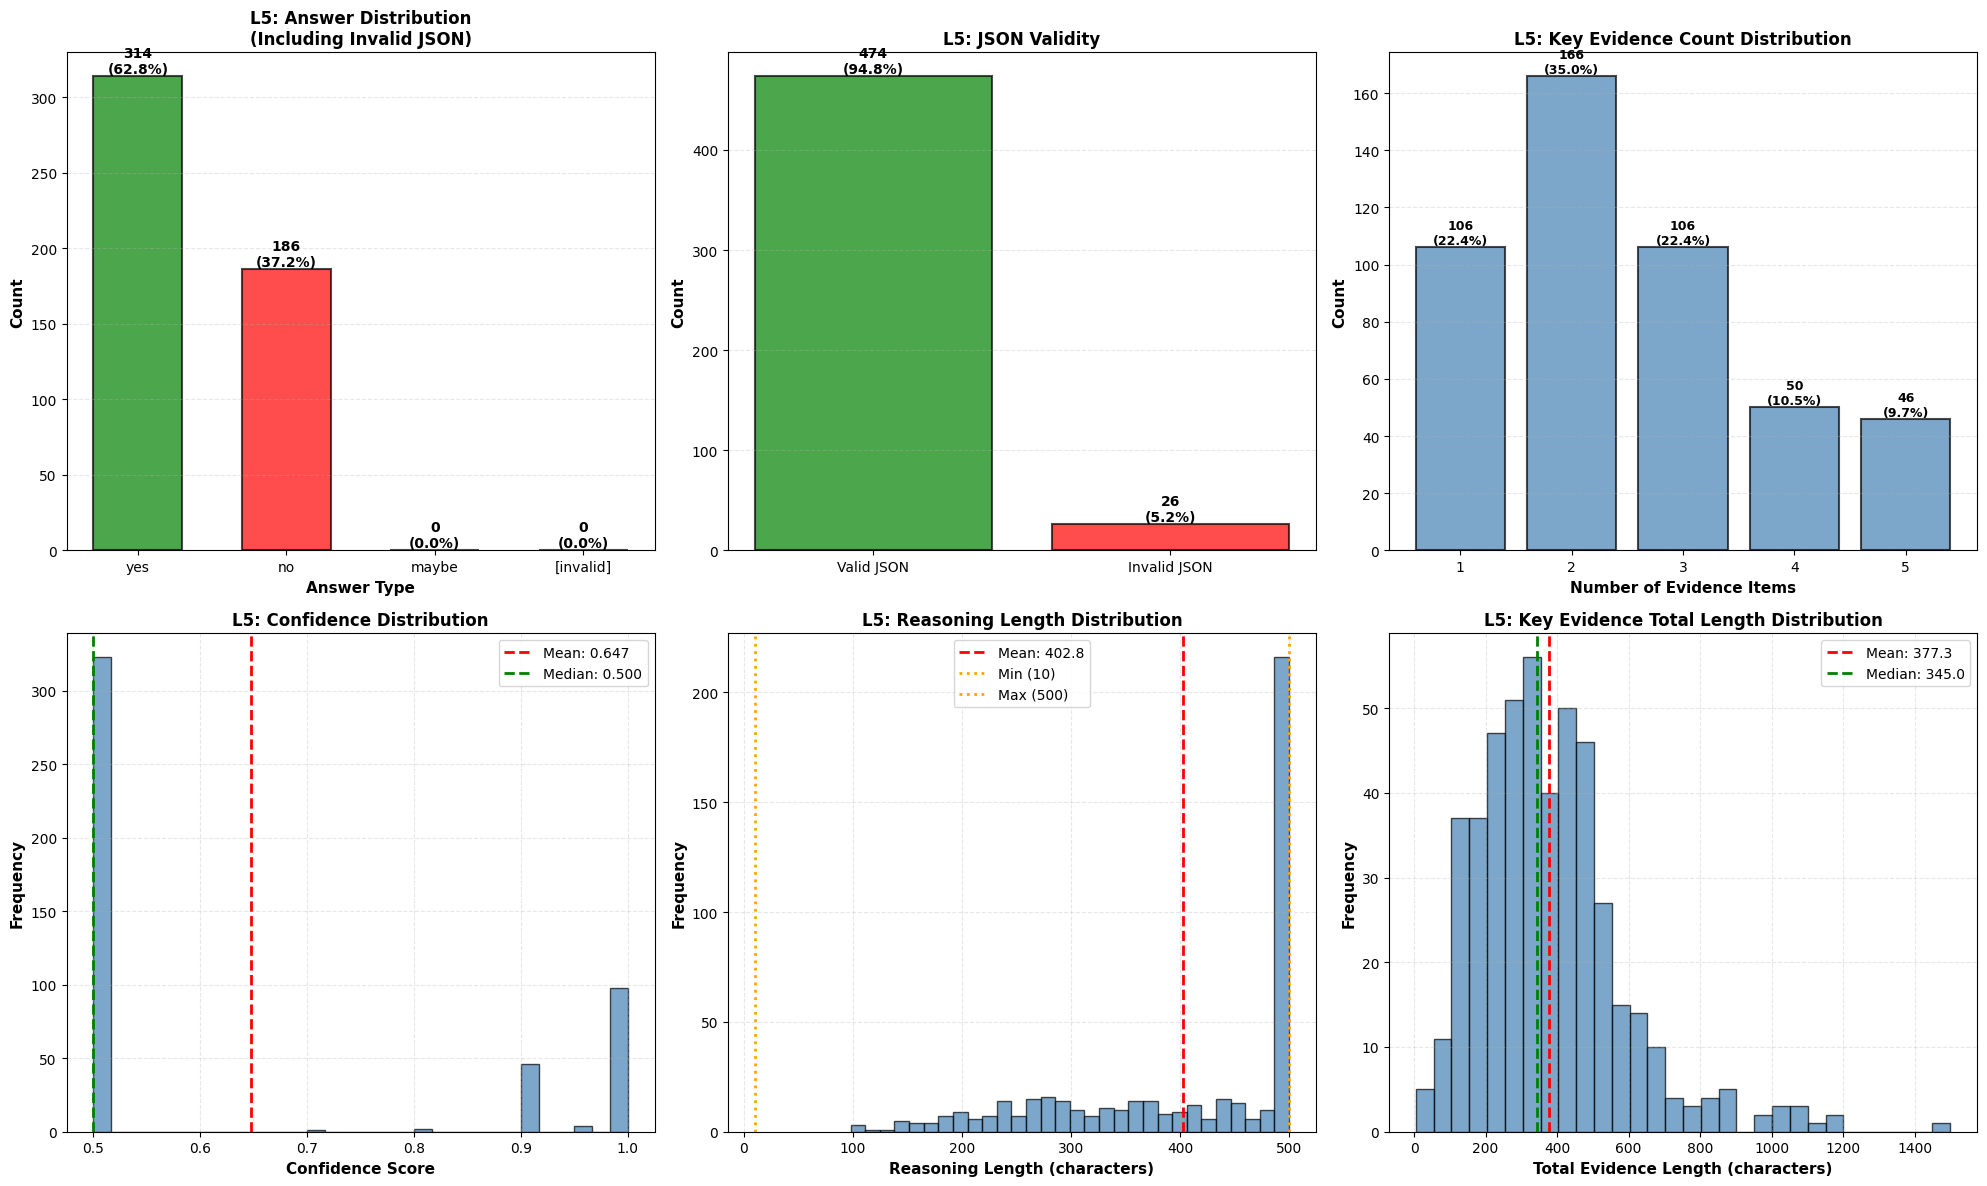

In [43]:
# Create visualizations for L5
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Answer Distribution
ax1 = axes[0, 0]
x_pos = np.arange(len(l5_categories))
bars1 = ax1.bar(x_pos, l5_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l5_counts):
    height = bar.get_height()
    percentage = count / l5_total * 100 if l5_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L5: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l5_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. JSON Validity
ax2 = axes[0, 1]
valid_count = l5_valid_json_count
invalid_count = l5_total - l5_valid_json_count
bars2 = ax2.bar(['Valid JSON', 'Invalid JSON'], [valid_count, invalid_count], 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, [valid_count, invalid_count]):
    height = bar.get_height()
    percentage = count / l5_total * 100 if l5_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L5: JSON Validity', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Key Evidence Count Distribution
ax3 = axes[0, 2]
if l5_valid_key_evidence_counts:
    count_dist = Counter(l5_valid_key_evidence_counts)
    count_vals = sorted(count_dist.keys())
    count_freqs = [count_dist[c] for c in count_vals]
    bars3 = ax3.bar([str(c) for c in count_vals], count_freqs, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    for bar, freq in zip(bars3, count_freqs):
        height = bar.get_height()
        percentage = freq / len(l5_valid_key_evidence_counts) * 100 if len(l5_valid_key_evidence_counts) > 0 else 0
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{freq}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.set_xlabel('Number of Evidence Items', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('L5: Key Evidence Count Distribution', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax3.text(0.5, 0.5, 'No valid\nkey_evidence lists', 
            ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('L5: Key Evidence Count Distribution', fontsize=12, fontweight='bold')
ax3.tick_params(labelsize=10)

# 4. Confidence Distribution Histogram
ax4 = axes[1, 0]
if l5_valid_confidences:
    ax4.hist(l5_valid_confidences, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax4.axvline(np.mean(l5_valid_confidences), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l5_valid_confidences):.3f}')
    ax4.axvline(np.median(l5_valid_confidences), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l5_valid_confidences):.3f}')
    ax4.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax4.set_title('L5: Confidence Distribution', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3, linestyle='--')
else:
    ax4.text(0.5, 0.5, 'No valid\nconfidence scores', 
            ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('L5: Confidence Distribution', fontsize=12, fontweight='bold')
ax4.tick_params(labelsize=10)

# 5. Reasoning Length Histogram
ax5 = axes[1, 1]
if l5_valid_reasoning_lengths:
    ax5.hist(l5_valid_reasoning_lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax5.axvline(np.mean(l5_valid_reasoning_lengths), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l5_valid_reasoning_lengths):.1f}')
    ax5.axvline(10, color='orange', linestyle=':', linewidth=2, label='Min (10)')
    ax5.axvline(500, color='orange', linestyle=':', linewidth=2, label='Max (500)')
    ax5.set_xlabel('Reasoning Length (characters)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax5.set_title('L5: Reasoning Length Distribution', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=10)
    ax5.grid(alpha=0.3, linestyle='--')
else:
    ax5.text(0.5, 0.5, 'No valid\nreasoning texts', 
            ha='center', va='center', transform=ax5.transAxes, fontsize=12)
    ax5.set_title('L5: Reasoning Length Distribution', fontsize=12, fontweight='bold')
ax5.tick_params(labelsize=10)

# 6. Key Evidence Total Length Histogram
ax6 = axes[1, 2]
if l5_valid_key_evidence_lengths:
    ax6.hist(l5_valid_key_evidence_lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax6.axvline(np.mean(l5_valid_key_evidence_lengths), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l5_valid_key_evidence_lengths):.1f}')
    ax6.axvline(np.median(l5_valid_key_evidence_lengths), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l5_valid_key_evidence_lengths):.1f}')
    ax6.set_xlabel('Total Evidence Length (characters)', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax6.set_title('L5: Key Evidence Total Length Distribution', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=10)
    ax6.grid(alpha=0.3, linestyle='--')
else:
    ax6.text(0.5, 0.5, 'No valid\nkey_evidence lists', 
            ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('L5: Key Evidence Total Length Distribution', fontsize=12, fontweight='bold')
ax6.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Load L6 Results


In [44]:
# Load L6 result JSON
l6_result_file = "pubmedqa_level6_2025-12-08T19-45-46.527366.json"

with open(l6_result_file, 'r') as f:
    l6_results = json.load(f)

l6_exact_match = l6_results['results']['pubmedqa_generation']['exact_match,strict-match']
l6_exact_match_stderr = l6_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L6 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l6_exact_match:.4f} ± {l6_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l6_exact_match*100:.2f}%")
print("="*60)


L6 PERFORMANCE METRICS
Exact Match Score: 0.7760 ± 0.0187
Exact Match Percentage: 77.60%


## L6 Answer Distribution Analysis (Including Invalid JSON)


In [45]:
# Load L6 samples and extract data
l6_samples_file = "samples_pubmedqa_generation_L6.jsonl"

l6_answers = []
l6_confidences = []
l6_reasonings = []
l6_reasoning_lengths = []
l6_key_evidence = []
l6_key_evidence_counts = []
l6_key_evidence_lengths = []
l6_valid_json = []
l6_has_answer = []
l6_has_confidence = []
l6_has_reasoning = []
l6_has_key_evidence = []
l6_answer_valid = []
l6_confidence_valid = []
l6_reasoning_valid = []
l6_key_evidence_valid = []
l6_responses = []
l6_filtered_responses = []

with open(l6_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        confidence = None
        reasoning = None
        reasoning_length = 0
        key_evidence_list = None
        key_evidence_count = 0
        key_evidence_total_length = 0
        has_answer_field = False
        has_confidence_field = False
        has_reasoning_field = False
        has_key_evidence_field = False
        answer_is_valid_enum = False
        confidence_is_valid = False
        reasoning_is_valid = False
        key_evidence_is_valid = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
                
                # Extract confidence (optional)
                confidence_val = parsed.get('confidence')
                if confidence_val is not None:
                    try:
                        confidence = float(confidence_val)
                        has_confidence_field = True
                        confidence_is_valid = (0.0 <= confidence <= 1.0)
                    except (ValueError, TypeError):
                        confidence = None
                        has_confidence_field = False
                        confidence_is_valid = False
                
                # Extract reasoning (optional)
                reasoning_val = parsed.get('reasoning')
                if reasoning_val is not None:
                    reasoning = str(reasoning_val).strip()
                    has_reasoning_field = True
                    reasoning_length = len(reasoning)
                    # L6 has no length constraint on reasoning (optional)
                    reasoning_is_valid = True
                
                # Extract key_evidence (optional)
                key_evidence_val = parsed.get('key_evidence')
                if key_evidence_val is not None:
                    if isinstance(key_evidence_val, list):
                        key_evidence_list = key_evidence_val
                        has_key_evidence_field = True
                        key_evidence_count = len(key_evidence_list)
                        # L6 has no count constraint on key_evidence (optional)
                        key_evidence_is_valid = True
                        # Calculate total length of all evidence items
                        key_evidence_total_length = sum([len(str(item)) for item in key_evidence_list])
                    else:
                        key_evidence_list = None
                        has_key_evidence_field = False
                        key_evidence_is_valid = False
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l6_answers.append(answer)
        l6_confidences.append(confidence)
        l6_reasonings.append(reasoning)
        l6_reasoning_lengths.append(reasoning_length)
        l6_key_evidence.append(key_evidence_list)
        l6_key_evidence_counts.append(key_evidence_count)
        l6_key_evidence_lengths.append(key_evidence_total_length)
        l6_valid_json.append(json_valid)
        l6_has_answer.append(has_answer_field)
        l6_has_confidence.append(has_confidence_field)
        l6_has_reasoning.append(has_reasoning_field)
        l6_has_key_evidence.append(has_key_evidence_field)
        l6_answer_valid.append(answer_is_valid_enum)
        l6_confidence_valid.append(confidence_is_valid)
        l6_reasoning_valid.append(reasoning_is_valid)
        l6_key_evidence_valid.append(key_evidence_is_valid)
        l6_responses.append(raw_resp if raw_resp else '')
        l6_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l6_answer_counts = Counter(l6_answers)
l6_categories = ['yes', 'no', 'maybe', '[invalid]']
l6_counts = [l6_answer_counts.get(cat, 0) for cat in l6_categories]

# Calculate schema compliance (L6 only requires answer, other fields are optional)
l6_total = len(l6_answers)
l6_valid_json_count = sum(l6_valid_json)
l6_compliant = sum([l6_valid_json[i] and l6_has_answer[i] and l6_answer_valid[i] 
                     for i in range(l6_total)])

print("="*60)
print("L6 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l6_categories, l6_counts):
    percentage = count / l6_total * 100 if l6_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l6_total}")
print(f"Valid answers (yes+no+maybe): {sum(l6_counts[:3])} ({sum(l6_counts[:3])/l6_total*100:.2f}%)")
print(f"Invalid answers: {l6_counts[3]} ({l6_counts[3]/l6_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l6_valid_json_count}/{l6_total} ({l6_valid_json_count/l6_total*100:.2f}%)")
print(f"  Invalid JSON: {l6_total - l6_valid_json_count}/{l6_total} ({(l6_total - l6_valid_json_count)/l6_total*100:.2f}%)")

print(f"\nSchema Compliance (L6: answer required, others optional):")
print(f"  Has answer field: {sum(l6_has_answer)}/{l6_total} ({sum(l6_has_answer)/l6_total*100:.2f}%)")
print(f"  Has confidence field (optional): {sum(l6_has_confidence)}/{l6_total} ({sum(l6_has_confidence)/l6_total*100:.2f}%)")
print(f"  Has reasoning field (optional): {sum(l6_has_reasoning)}/{l6_total} ({sum(l6_has_reasoning)/l6_total*100:.2f}%)")
print(f"  Has key_evidence field (optional): {sum(l6_has_key_evidence)}/{l6_total} ({sum(l6_has_key_evidence)/l6_total*100:.2f}%)")
print(f"  Answer is valid enum: {sum(l6_answer_valid)}/{l6_total} ({sum(l6_answer_valid)/l6_total*100:.2f}%)")
print(f"  Confidence in range [0.0, 1.0] (when present): {sum(l6_confidence_valid)}/{sum(l6_has_confidence) if sum(l6_has_confidence) > 0 else 1} ({sum(l6_confidence_valid)/sum(l6_has_confidence)*100:.2f}% of those with confidence)" if sum(l6_has_confidence) > 0 else "  Confidence in range [0.0, 1.0] (when present): N/A (no confidence fields)")
print(f"  Full schema compliance (answer required): {l6_compliant}/{l6_total} ({l6_compliant/l6_total*100:.2f}%)")
print("="*60)


L6 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  313 (62.60%)
  no          :  187 (37.40%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 417/500 (83.40%)
  Invalid JSON: 83/500 (16.60%)

Schema Compliance (L6: answer required, others optional):
  Has answer field: 417/500 (83.40%)
  Has confidence field (optional): 0/500 (0.00%)
  Has reasoning field (optional): 0/500 (0.00%)
  Has key_evidence field (optional): 0/500 (0.00%)
  Answer is valid enum: 417/500 (83.40%)
  Confidence in range [0.0, 1.0] (when present): N/A (no confidence fields)
  Full schema compliance (answer required): 417/500 (83.40%)


## L6 Optional Fields Statistics


In [46]:
# Statistics for L6 (all fields optional except answer)
l6_valid_confidences = [c for c in l6_confidences if c is not None]
l6_valid_reasoning_lengths = [l6_reasoning_lengths[i] for i, r in enumerate(l6_reasonings) if r is not None]
l6_valid_key_evidence_counts = [l6_key_evidence_counts[i] for i, ke in enumerate(l6_key_evidence) if ke is not None]
l6_valid_key_evidence_lengths = [l6_key_evidence_lengths[i] for i, ke in enumerate(l6_key_evidence) if ke is not None]

print("="*60)
print("L6 OPTIONAL FIELDS PRESENCE")
print("="*60)
print(f"Confidence present: {sum(l6_has_confidence)}/{l6_total} ({sum(l6_has_confidence)/l6_total*100:.1f}%)")
print(f"Reasoning present: {sum(l6_has_reasoning)}/{l6_total} ({sum(l6_has_reasoning)/l6_total*100:.1f}%)")
print(f"Key evidence present: {sum(l6_has_key_evidence)}/{l6_total} ({sum(l6_has_key_evidence)/l6_total*100:.1f}%)")
print(f"All optional fields present: {sum([l6_has_confidence[i] and l6_has_reasoning[i] and l6_has_key_evidence[i] for i in range(l6_total)])}/{l6_total} ({sum([l6_has_confidence[i] and l6_has_reasoning[i] and l6_has_key_evidence[i] for i in range(l6_total)])/l6_total*100:.1f}%)")

print("\n" + "="*60)
print("L6 CONFIDENCE SCORE STATISTICS (when present)")
print("="*60)

if l6_valid_confidences:
    print(f"Valid confidence scores: {len(l6_valid_confidences)} ({len(l6_valid_confidences)/l6_total*100:.1f}%)")
    print(f"\nDescriptive Statistics:")
    print(f"  Mean: {np.mean(l6_valid_confidences):.4f}")
    print(f"  Median: {np.median(l6_valid_confidences):.4f}")
    print(f"  Std Dev: {np.std(l6_valid_confidences):.4f}")
    print(f"  Min: {np.min(l6_valid_confidences):.4f}")
    print(f"  Max: {np.max(l6_valid_confidences):.4f}")
    print(f"  Range: {np.max(l6_valid_confidences) - np.min(l6_valid_confidences):.4f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l6_valid_confidences, p):.4f}")
    
    # Confidence by answer type
    print(f"\nConfidence by Answer Type:")
    for answer_type in ['yes', 'no', 'maybe']:
        conf_by_type = [l6_confidences[i] for i, ans in enumerate(l6_answers) 
                       if ans == answer_type and l6_confidences[i] is not None]
        if conf_by_type:
            print(f"  {answer_type}: mean={np.mean(conf_by_type):.4f}, median={np.median(conf_by_type):.4f}, count={len(conf_by_type)}")
        else:
            print(f"  {answer_type}: No valid confidence scores")
else:
    print("No valid confidence scores found!")

print("\n" + "="*60)
print("L6 REASONING LENGTH STATISTICS (when present)")
print("="*60)

if l6_valid_reasoning_lengths:
    print(f"Valid reasoning texts: {len(l6_valid_reasoning_lengths)} ({len(l6_valid_reasoning_lengths)/l6_total*100:.1f}%)")
    print(f"\nDescriptive Statistics (characters):")
    print(f"  Mean: {np.mean(l6_valid_reasoning_lengths):.2f}")
    print(f"  Median: {np.median(l6_valid_reasoning_lengths):.2f}")
    print(f"  Std Dev: {np.std(l6_valid_reasoning_lengths):.2f}")
    print(f"  Min: {np.min(l6_valid_reasoning_lengths):.0f}")
    print(f"  Max: {np.max(l6_valid_reasoning_lengths):.0f}")
    print(f"  Range: {np.max(l6_valid_reasoning_lengths) - np.min(l6_valid_reasoning_lengths):.0f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l6_valid_reasoning_lengths, p):.2f}")
else:
    print("No valid reasoning texts found!")

print("\n" + "="*60)
print("L6 KEY EVIDENCE STATISTICS (when present)")
print("="*60)

if l6_valid_key_evidence_counts:
    print(f"Valid key_evidence lists: {len(l6_valid_key_evidence_counts)} ({len(l6_valid_key_evidence_counts)/l6_total*100:.1f}%)")
    print(f"\nEvidence Count Statistics (items per sample):")
    print(f"  Mean: {np.mean(l6_valid_key_evidence_counts):.2f}")
    print(f"  Median: {np.median(l6_valid_key_evidence_counts):.2f}")
    print(f"  Std Dev: {np.std(l6_valid_key_evidence_counts):.2f}")
    print(f"  Min: {np.min(l6_valid_key_evidence_counts):.0f}")
    print(f"  Max: {np.max(l6_valid_key_evidence_counts):.0f}")
    print(f"  Range: {np.max(l6_valid_key_evidence_counts) - np.min(l6_valid_key_evidence_counts):.0f}")
    print(f"\nEvidence Count Distribution:")
    count_dist = Counter(l6_valid_key_evidence_counts)
    for count_val in sorted(count_dist.keys()):
        print(f"  {count_val} item(s): {count_dist[count_val]} samples ({count_dist[count_val]/len(l6_valid_key_evidence_counts)*100:.1f}%)")
    
    print(f"\nEvidence Total Length Statistics (characters per sample):")
    print(f"  Mean: {np.mean(l6_valid_key_evidence_lengths):.2f}")
    print(f"  Median: {np.median(l6_valid_key_evidence_lengths):.2f}")
    print(f"  Std Dev: {np.std(l6_valid_key_evidence_lengths):.2f}")
    print(f"  Min: {np.min(l6_valid_key_evidence_lengths):.0f}")
    print(f"  Max: {np.max(l6_valid_key_evidence_lengths):.0f}")
    print(f"  Range: {np.max(l6_valid_key_evidence_lengths) - np.min(l6_valid_key_evidence_lengths):.0f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l6_valid_key_evidence_lengths, p):.2f}")
else:
    print("No valid key_evidence lists found!")
print("="*60)


L6 OPTIONAL FIELDS PRESENCE
Confidence present: 0/500 (0.0%)
Reasoning present: 0/500 (0.0%)
Key evidence present: 0/500 (0.0%)
All optional fields present: 0/500 (0.0%)

L6 CONFIDENCE SCORE STATISTICS (when present)
No valid confidence scores found!

L6 REASONING LENGTH STATISTICS (when present)
No valid reasoning texts found!

L6 KEY EVIDENCE STATISTICS (when present)
No valid key_evidence lists found!


## L6 Visualizations


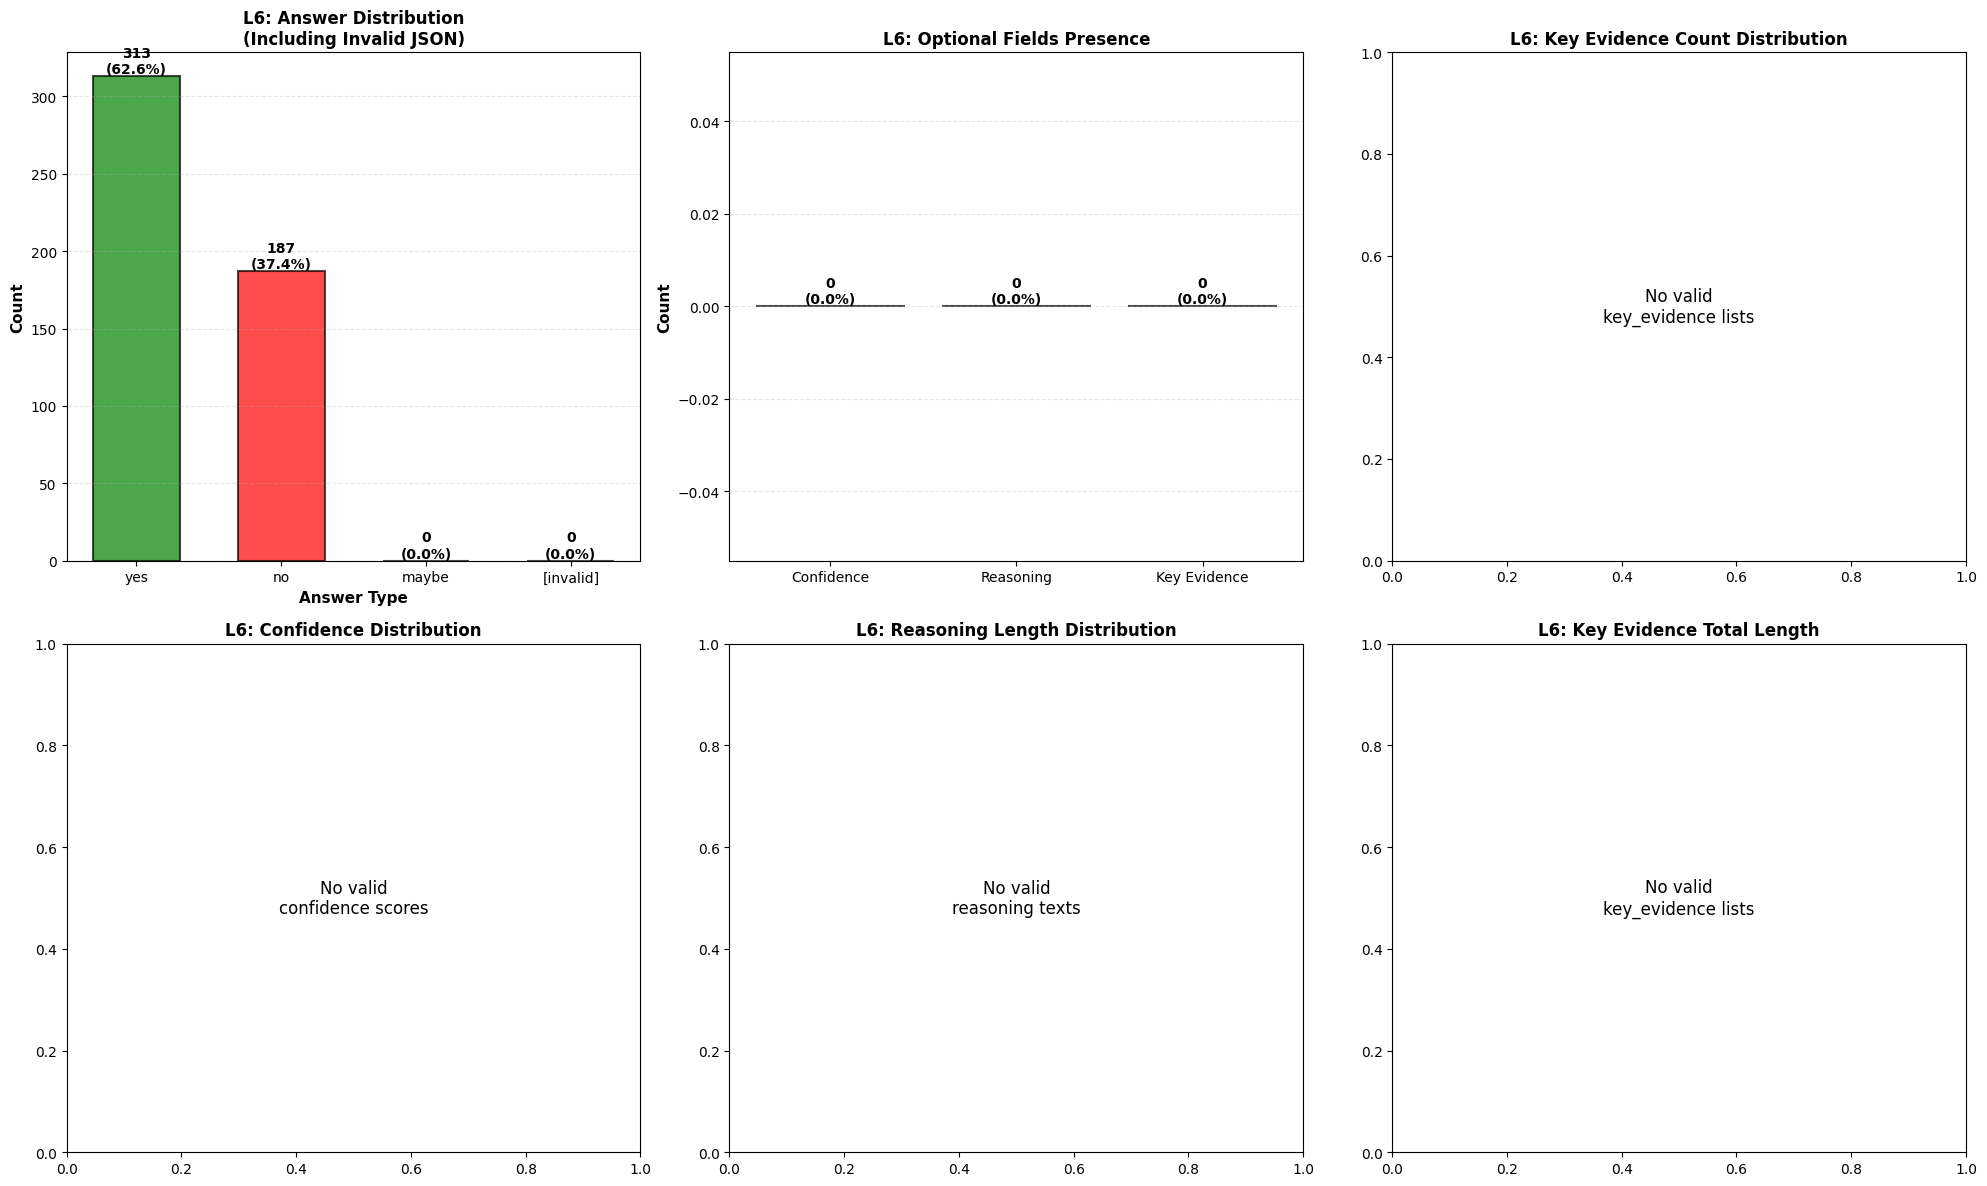

In [47]:
# Create visualizations for L6
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Answer Distribution
ax1 = axes[0, 0]
x_pos = np.arange(len(l6_categories))
bars1 = ax1.bar(x_pos, l6_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l6_counts):
    height = bar.get_height()
    percentage = count / l6_total * 100 if l6_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L6: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l6_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. Optional Fields Presence
ax2 = axes[0, 1]
optional_fields = ['Confidence', 'Reasoning', 'Key Evidence']
optional_counts = [sum(l6_has_confidence), sum(l6_has_reasoning), sum(l6_has_key_evidence)]
bars2 = ax2.bar(optional_fields, optional_counts, color=['steelblue', 'orange', 'purple'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, optional_counts):
    height = bar.get_height()
    percentage = count / l6_total * 100 if l6_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L6: Optional Fields Presence', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Key Evidence Count Distribution (when present)
ax3 = axes[0, 2]
if l6_valid_key_evidence_counts:
    count_dist = Counter(l6_valid_key_evidence_counts)
    count_vals = sorted(count_dist.keys())
    count_freqs = [count_dist[c] for c in count_vals]
    bars3 = ax3.bar([str(c) for c in count_vals], count_freqs, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    for bar, freq in zip(bars3, count_freqs):
        height = bar.get_height()
        percentage = freq / len(l6_valid_key_evidence_counts) * 100 if len(l6_valid_key_evidence_counts) > 0 else 0
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{freq}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.set_xlabel('Number of Evidence Items', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('L6: Key Evidence Count Distribution\n(when present)', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax3.text(0.5, 0.5, 'No valid\nkey_evidence lists', 
            ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('L6: Key Evidence Count Distribution', fontsize=12, fontweight='bold')
ax3.tick_params(labelsize=10)

# 4. Confidence Distribution Histogram (when present)
ax4 = axes[1, 0]
if l6_valid_confidences:
    ax4.hist(l6_valid_confidences, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax4.axvline(np.mean(l6_valid_confidences), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l6_valid_confidences):.3f}')
    ax4.axvline(np.median(l6_valid_confidences), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l6_valid_confidences):.3f}')
    ax4.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax4.set_title('L6: Confidence Distribution\n(when present)', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3, linestyle='--')
else:
    ax4.text(0.5, 0.5, 'No valid\nconfidence scores', 
            ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('L6: Confidence Distribution', fontsize=12, fontweight='bold')
ax4.tick_params(labelsize=10)

# 5. Reasoning Length Histogram (when present)
ax5 = axes[1, 1]
if l6_valid_reasoning_lengths:
    ax5.hist(l6_valid_reasoning_lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax5.axvline(np.mean(l6_valid_reasoning_lengths), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l6_valid_reasoning_lengths):.1f}')
    ax5.axvline(np.median(l6_valid_reasoning_lengths), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l6_valid_reasoning_lengths):.1f}')
    ax5.set_xlabel('Reasoning Length (characters)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax5.set_title('L6: Reasoning Length Distribution\n(when present)', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=10)
    ax5.grid(alpha=0.3, linestyle='--')
else:
    ax5.text(0.5, 0.5, 'No valid\nreasoning texts', 
            ha='center', va='center', transform=ax5.transAxes, fontsize=12)
    ax5.set_title('L6: Reasoning Length Distribution', fontsize=12, fontweight='bold')
ax5.tick_params(labelsize=10)

# 6. Key Evidence Total Length Histogram (when present)
ax6 = axes[1, 2]
if l6_valid_key_evidence_lengths:
    ax6.hist(l6_valid_key_evidence_lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax6.axvline(np.mean(l6_valid_key_evidence_lengths), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l6_valid_key_evidence_lengths):.1f}')
    ax6.axvline(np.median(l6_valid_key_evidence_lengths), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l6_valid_key_evidence_lengths):.1f}')
    ax6.set_xlabel('Total Evidence Length (characters)', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax6.set_title('L6: Key Evidence Total Length\n(when present)', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=10)
    ax6.grid(alpha=0.3, linestyle='--')
else:
    ax6.text(0.5, 0.5, 'No valid\nkey_evidence lists', 
            ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('L6: Key Evidence Total Length', fontsize=12, fontweight='bold')
ax6.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Comprehensive Comparison: Baseline vs L1-L6


In [48]:
# Comprehensive Comparison: Baseline vs L1-L6
print("="*100)
print("COMPREHENSIVE COMPARISON: BASELINE vs L1-L6")
print("="*100)

# Collect all exact match scores
all_levels = ['Baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
all_exact_matches = [baseline_exact_match, l1_exact_match, l2_exact_match, l3_exact_match, l4_exact_match, l5_exact_match, l6_exact_match]
all_exact_match_stderrs = [baseline_exact_match_stderr, l1_exact_match_stderr, l2_exact_match_stderr, l3_exact_match_stderr, l4_exact_match_stderr, l5_exact_match_stderr, l6_exact_match_stderr]

print(f"\n📊 Task Performance (Exact Match):")
print(f"   {'Level':<12} {'Exact Match':<20} {'Percentage':<15}")
print(f"   {'-'*12} {'-'*20} {'-'*15}")
for level, em, stderr in zip(all_levels, all_exact_matches, all_exact_match_stderrs):
    print(f"   {level:<12} {em:.4f} ± {stderr:.4f}    {em*100:.2f}%")

print(f"\n   Differences vs Baseline:")
for i, level in enumerate(all_levels[1:], 1):
    diff = (all_exact_matches[i] - baseline_exact_match) * 100
    print(f"   {level} vs Baseline: {diff:+.2f} percentage points")

print(f"\n📈 Answer Distribution:")
print(f"   {'Category':<15} {'Baseline':<12} {'L1':<12} {'L2':<12} {'L3':<12} {'L4':<12} {'L5':<12} {'L6':<12}")
print(f"   {'-'*15} {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")
all_counts = [baseline_counts, l1_counts, l2_counts, l3_counts, l4_counts, l5_counts, l6_counts]
all_totals = [baseline_total, l1_total, l2_total, l3_total, l4_total, l5_total, l6_total]
for i, cat in enumerate(baseline_categories):
    row = f"   {cat:<15}"
    for counts, total in zip(all_counts, all_totals):
        count = counts[i] if i < len(counts) else 0
        pct = count / total * 100 if total > 0 else 0
        row += f" {count:4d} ({pct:5.2f}%)"
    print(row)

print(f"\n   {'Total':<15}", end="")
for total in all_totals:
    print(f" {total:<12}", end="")
print()

print(f"\n🔍 Schema Compliance:")
print(f"   {'Metric':<35} {'L1':<12} {'L2':<12} {'L3':<12} {'L4':<12} {'L5':<12} {'L6':<12}")
print(f"   {'-'*35} {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")
all_valid_json = [l1_valid_json_count, l2_valid_json_count, l3_valid_json_count, l4_valid_json_count, l5_valid_json_count, l6_valid_json_count]
all_compliant = [l1_compliant, l2_compliant, l3_compliant, l4_compliant, l5_compliant, l6_compliant]
schema_totals = all_totals[1:]  # Skip baseline

print(f"   {'Valid JSON':<35}", end="")
for valid_json, total in zip(all_valid_json, schema_totals):
    pct = valid_json / total * 100 if total > 0 else 0
    print(f" {valid_json}/{total} ({pct:5.2f}%)", end="")
print()

print(f"   {'Full Schema Compliance':<35}", end="")
for compliant, total in zip(all_compliant, schema_totals):
    pct = compliant / total * 100 if total > 0 else 0
    print(f" {compliant}/{total} ({pct:5.2f}%)", end="")
print()

# Additional metrics for levels with confidence
print(f"\n   {'Confidence (when present)':<35}", end="")
confidence_levels = [
    (l2_valid_confidences, l2_total, "L2"),
    (l4_valid_confidences, l4_total, "L4"),
    (l5_valid_confidences, l5_total, "L5"),
    (l6_valid_confidences, l6_total, "L6")
]
for conf_list, total, level_name in confidence_levels:
    if conf_list:
        mean_conf = np.mean(conf_list)
        count = len(conf_list)
        pct = count / total * 100 if total > 0 else 0
        print(f" {level_name}: {count}/{total} ({pct:.1f}%), μ={mean_conf:.3f}", end="")
print()

# Key evidence presence for L5 and L6
print(f"\n   {'Key Evidence (when present)':<35}", end="")
key_evidence_levels = [
    (l5_valid_key_evidence_counts, l5_total, "L5"),
    (l6_valid_key_evidence_counts, l6_total, "L6")
]
for ke_counts, total, level_name in key_evidence_levels:
    if ke_counts:
        count = len(ke_counts)
        pct = count / total * 100 if total > 0 else 0
        mean_count = np.mean(ke_counts)
        print(f" {level_name}: {count}/{total} ({pct:.1f}%), μ_items={mean_count:.1f}", end="")
print()

print("="*100)


COMPREHENSIVE COMPARISON: BASELINE vs L1-L6

📊 Task Performance (Exact Match):
   Level        Exact Match          Percentage     
   ------------ -------------------- ---------------
   Baseline     0.7620 ± 0.0191    76.20%
   L1           0.7720 ± 0.0188    77.20%
   L2           0.7740 ± 0.0187    77.40%
   L3           0.7720 ± 0.0188    77.20%
   L4           0.7740 ± 0.0187    77.40%
   L5           0.7740 ± 0.0187    77.40%
   L6           0.7760 ± 0.0187    77.60%

   Differences vs Baseline:
   L1 vs Baseline: +1.00 percentage points
   L2 vs Baseline: +1.20 percentage points
   L3 vs Baseline: +1.00 percentage points
   L4 vs Baseline: +1.20 percentage points
   L5 vs Baseline: +1.20 percentage points
   L6 vs Baseline: +1.40 percentage points

📈 Answer Distribution:
   Category        Baseline     L1           L2           L3           L4           L5           L6          
   --------------- ------------ ------------ ------------ ------------ ------------ ------------ ---

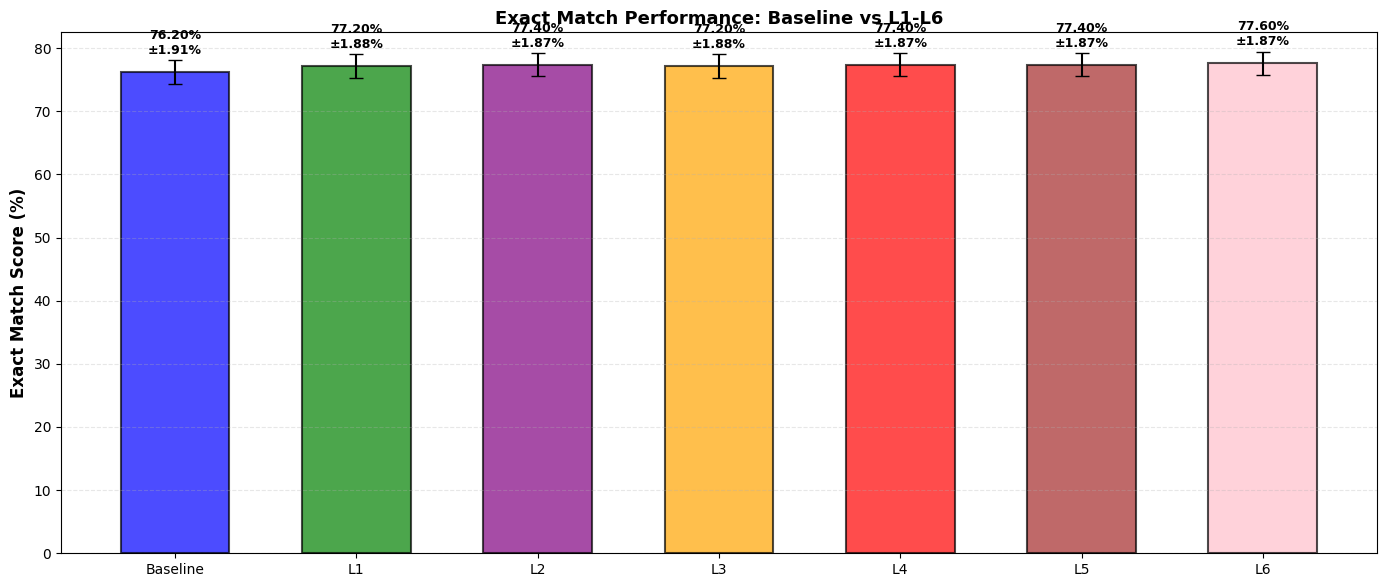

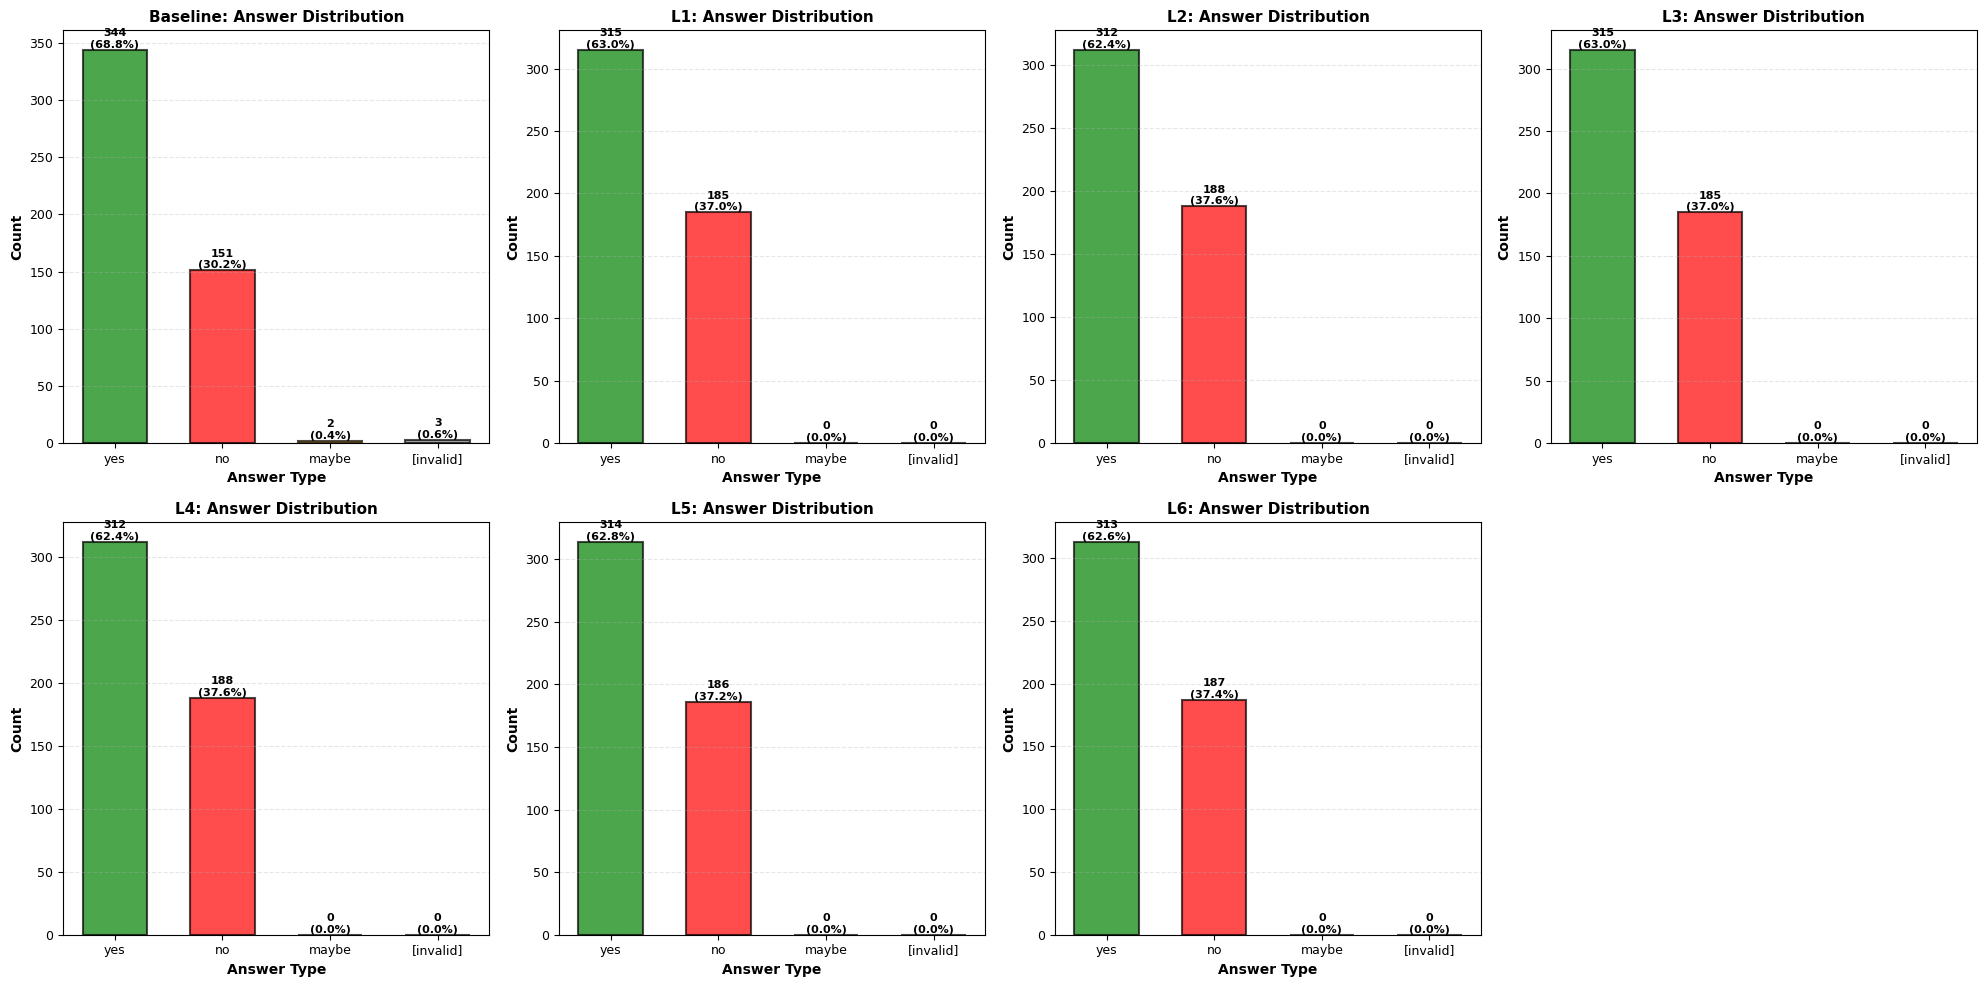

In [49]:
# Visualize Comprehensive Comparison: Baseline vs L1-L6
# 1. Exact Match Performance Comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

x_pos = np.arange(len(all_levels))
colors = ['blue', 'green', 'purple', 'orange', 'red', 'brown', 'pink']
bars = ax.bar(x_pos, [em * 100 for em in all_exact_matches], 
              yerr=[stderr * 100 for stderr in all_exact_match_stderrs],
              capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)

for i, (bar, em, stderr) in enumerate(zip(bars, all_exact_matches, all_exact_match_stderrs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + stderr * 100 + 0.5,
            f'{em*100:.2f}%\n±{stderr*100:.2f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Exact Match Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Exact Match Performance: Baseline vs L1-L6', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(all_levels, fontsize=11)
ax.set_ylim([0, max([em * 100 for em in all_exact_matches]) + max([stderr * 100 for stderr in all_exact_match_stderrs]) + 3])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# 2. Answer Distribution Comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

all_distributions = [
    ('Baseline', baseline_counts, baseline_total, baseline_categories),
    ('L1', l1_counts, l1_total, l1_categories),
    ('L2', l2_counts, l2_total, l2_categories),
    ('L3', l3_counts, l3_total, l3_categories),
    ('L4', l4_counts, l4_total, l4_categories),
    ('L5', l5_counts, l5_total, l5_categories),
    ('L6', l6_counts, l6_total, l6_categories),
]

for idx, (level_name, counts, total, categories) in enumerate(all_distributions):
    ax = axes[idx]
    x_pos = np.arange(len(categories))
    bars = ax.bar(x_pos, counts, color=['green', 'red', 'orange', 'gray'], 
                  alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        percentage = count / total * 100 if total > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xlabel('Answer Type', fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10, fontweight='bold')
    ax.set_title(f'{level_name}: Answer Distribution', fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories, fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=9)

# Hide the last subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()
